# White-matter bundles, layer-1 data-correctness validation

One question:

> **Does every glyph node carry the diffusion profile and the bundle spread that were
> actually measured at that same bundle-core node?**

No comparison against other encodings, no users. Two things have to be kept apart and
this notebook keeps them apart deliberately:

| | question | what a pass means |
|---|---|---|
| **A. mapping** | are FA, AD, RD and dispersion attached to the right core node? | the glyph draws the data it claims to draw |
| **B. identity** | is this path really the named anatomical bundle? | you may call it by that name |

**A** is settled here. **B** is answered in section 10 by an actual HCP842 atlas
comparison, and the answer is a number per bundle rather than a promise.

### What changed since the first round of this validation

The first run of this notebook found that the artefact could not be regenerated: dipy's
`deterministic_tracking` returns a different tractogram on every call, so bundle
membership, the cores and the profiles all moved between runs, and two to four of the
eight cores came back with node 0 and node 59 swapped. The producing notebook now

* **persists the streamlines it exported from** (`Scripts/wm_reconstruction/`, with a
  manifest and a SHA-256) and rebuilds from them, so artefact, geometry and this
  notebook describe one reconstruction;
* **orients every core from its first waypoint ROI to its last**, so node 0 is an
  anatomical end rather than a QuickBundles accident;
* **exports the measured along-tract slip per bundle**, so a node is documented as a
  local segment.

This notebook checks all three, and keeps the run-to-run instability itself as a
measured quantity in section 9 rather than as an assumption.

### Layers of the validation

Sections 1 and 8 read the artefact alone (`wm_tract_glyph.json`,
`wm_tract_geometry.json`) and need nothing else. Sections 2-7 load the persisted
reconstruction and recompute the profiles *independently* -- own sampling code, own
weights, own dispersion. Section 9 (`RETRACK = True`, ~8 min) tracks again to measure
how much a rebuild would move things, and section 10 (`ATLAS_CHECK = True`, ~5 min)
registers the subject to the HCP842 atlas.

## 0. Setup

In [1]:
import datetime
import hashlib
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.ndimage import map_coordinates
from scipy.spatial import cKDTree
from scipy.stats import rankdata, spearmanr
from nibabel.affines import apply_affine

try:
    display
except NameError:
    display = print

warnings.filterwarnings("ignore")
RNG = np.random.default_rng(11)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

SOURCE_NB = Path("wm_tract_bundle_glyph.ipynb")
GLYPH_JSON = Path("../Frontend/public/wm_tract_glyph.json")
GEOM_JSON = Path("../Frontend/public/wm_tract_geometry.json")
assert SOURCE_NB.exists() and GLYPH_JSON.exists(), "run this notebook from Scripts/"

PIPELINE = True       # load the persisted reconstruction and its pipeline code
RETRACK = True        # track again to measure the rebuild spread in section 9 (~8 min)
ATLAS_CHECK = True    # register to the HCP842 atlas in section 10 (~5 min, 2 GB fetched)

TOL_ROUND = 5e-5      # values and coordinates are written with 4 decimals
TOL_RAW = 5e-9        # raw_values are written with 8 decimals
CHECKS = []


def record(name, passed, detail="", tol="", level="FAIL"):
    """`level` is what a negative result means: FAIL = the data are wrong, WARN = the
    artefact disagrees with its provenance or its own documentation."""
    result = "PASS" if passed else level
    CHECKS.append(dict(check=name, result=result, detail=detail, tolerance=str(tol)))
    print(f"[{result}] {name}   {detail}")

In [2]:
GL = json.load(open(GLYPH_JSON))
GEO = json.load(open(GEOM_JSON))
META = GL["meta"]
CH_USE = GL["channels"]
CH_ALL = list(GL["objects"][0]["points"][0]["attributes"]["raw_values"])
N_NODES = int(META["nNodes"])
KEYS = [o["key"] for o in GL["objects"]]

CORE = np.array([[[p["x"], p["y"], p["z"]] for p in o["points"]] for o in GL["objects"]])
VAL = np.array([[p["values"] for p in o["points"]] for o in GL["objects"]])
RAWJ = np.array([[[p["attributes"]["raw_values"][c] for c in CH_ALL]
                  for p in o["points"]] for o in GL["objects"]])
ATTR = {k: np.array([[p["attributes"][k] for p in o["points"]] for o in GL["objects"]])
        for k in ("node", "arclen", "percent", "coreRadiusP75", "dispersionMedian")}
n_obj = len(KEYS)

print(f"{n_obj} bundles x {N_NODES} nodes")
print("glyph channels   :", CH_USE)
print("measured channels:", CH_ALL)
for o in GL["objects"]:
    print(f"  {o['objectId']}  {o['key']:20s} {o['nStreamlines']:5d} streamlines   "
          f"{o['label']}")

8 bundles x 60 nodes
glyph channels   : ['FA', 'AD', 'RD', 'dispersion']
measured channels: ['FA', 'MD', 'AD', 'RD', 'dispersion', 'curvature', 'support_fraction']
  0  cc_forceps_minor      3833 streamlines   Callosal route, frontal ROIs (atlas: CCMid)
  1  cc_body_motor         3597 streamlines   CC body (motor/premotor) (approx.)
  2  cc_parietal           4020 streamlines   Callosal route, parietal ROIs (no atlas match)
  3  cc_forceps_major       512 streamlines   CC forceps major (occipital) (approx.)
  4  cingulum_l             586 streamlines   Left cingulum (approx.)
  5  cingulum_r             561 streamlines   Right cingulum (approx.)
  6  thalamo_prec_l         482 streamlines   L thalamus-precentral route (no atlas match)
  7  thalamo_prec_r         298 streamlines   R thalamus-precentral route (no atlas match)


## 1. What the artefact says about itself

These checks need nothing but the two JSON files, and they already cover a large part
of "the glyph is not drawing the wrong number in the wrong place": the export ships
`attributes.raw_values` next to `values`, so the rank transform, the channel
assignment, the node ordering and the geometry file can all be verified against the
measurements the export itself carries.

In [3]:
ok_struct = (META["nObjects"] == n_obj
             and META["nPointsPerObject"] == [N_NODES] * n_obj
             and len(set(KEYS)) == n_obj
             and [o["objectId"] for o in GL["objects"]] == list(range(n_obj)))
record("structure: objectIds are 0..n-1, keys unique, node counts match meta",
       ok_struct, f"{n_obj} objects, {N_NODES} nodes each")

record("node index, percent and arclen are consistent per bundle",
       bool((ATTR["node"] == np.arange(N_NODES)).all()
            and np.abs(ATTR["percent"] - 100 * np.arange(N_NODES) / (N_NODES - 1)).max() < 0.01
            and (np.diff(ATTR["arclen"], axis=1) > 0).all()),
       "node = 0..59 in order, percent = 100*node/59, arclen strictly increasing")

seg = np.linalg.norm(np.diff(CORE, axis=1), axis=-1)
arclen_recomputed = np.c_[np.zeros(n_obj), np.cumsum(seg, axis=1)]
err_arc = np.abs(arclen_recomputed - ATTR["arclen"]).max()
record("stored arclen equals the path length of the stored core coordinates",
       err_arc < 1e-3,
       f"max |recomputed - stored| = {err_arc:.2e} mm (coordinates are written with "
       "4 decimals, so ~1e-4 mm accumulates over 60 nodes)", "1e-3 mm")

md = RAWJ[..., CH_ALL.index("MD")]
md_id = (RAWJ[..., CH_ALL.index("AD")] + 2 * RAWJ[..., CH_ALL.index("RD")]) / 3
record("MD = (AD + 2 RD) / 3 holds in the exported raw values",
       np.abs(md - md_id).max() < 1e-8,
       f"max residual = {np.abs(md - md_id).max():.2e} mm^2/s -- the three tensor "
       "scalars come from one eigendecomposition, as documented", "1e-8")

[PASS] structure: objectIds are 0..n-1, keys unique, node counts match meta   8 objects, 60 nodes each
[PASS] node index, percent and arclen are consistent per bundle   node = 0..59 in order, percent = 100*node/59, arclen strictly increasing
[PASS] stored arclen equals the path length of the stored core coordinates   max |recomputed - stored| = 1.66e-04 mm (coordinates are written with 4 decimals, so ~1e-4 mm accumulates over 60 nodes)
[PASS] MD = (AD + 2 RD) / 3 holds in the exported raw values   max residual = 6.67e-09 mm^2/s -- the three tensor scalars come from one eigendecomposition, as documented


### 1.1 Is `values[j]` the rank of `raw_values[channel j]`?

The export rank-normalises jointly over every node of every bundle. That is exactly
reproducible from the raw values the file itself carries, so this is not a plausibility
argument but an identity: `values[:, j] == rankdata(raw[:, j]) / n_nodes_total`.

rank / n: 0 nodes off  (rank - 0.5) / n: 1915 nodes off
[PASS] every glyph value is the global rank of its own raw value   yes, under the 'rank / n' convention: all 480 nodes x 4 channels agree, max |rank(raw) - values| = 1.08e-03 (10 node-channels share a raw value at the 8-decimal write precision and are allowed half a rank step)
[PASS] the artefact uses the rank convention the current notebook writes   both use 'rank / n'


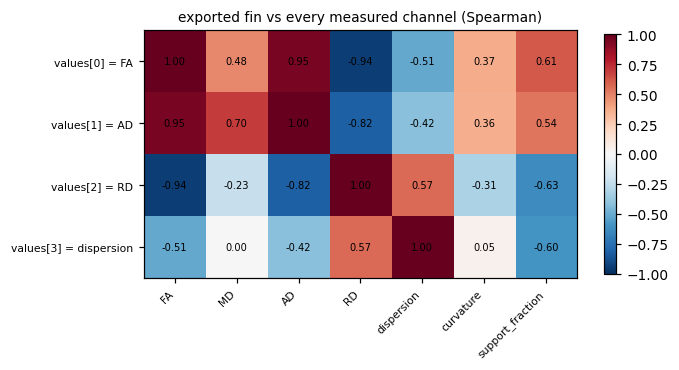

[PASS] fin j carries channel j (no rotated or swapped fins)   min diagonal Spearman = 1.000000; largest off-diagonal = 0.95 (FA/AD/RD are genuinely correlated in a single-subject tensor fit, which is why the diagonal, not the contrast, is the test)


In [4]:
RAW_USE = np.stack([RAWJ[..., CH_ALL.index(c)] for c in CH_USE], axis=-1)
flat_raw = RAW_USE.reshape(-1, len(CH_USE))
n_total = flat_raw.shape[0]

# Two conventions are in circulation for turning a rank into a percentile, and they
# differ by half a rank step. Rather than assume one, both are scored and the file is
# asked which one it used -- a difference of exactly 0.5/n is a convention, a difference
# of anything else is an error.
CONVENTIONS = {"rank / n": lambda r: r / n_total,
               "(rank - 0.5) / n": lambda r: (r - 0.5) / n_total}


def rank_tolerance(raw_column):
    """Per-node tolerance for the rank comparison.

    `raw_values` are written with 8 decimals while the ranking was computed on full
    precision, so two nodes can share a stored raw value and still, correctly, hold
    different percentiles. For those nodes `rankdata` here returns the average rank and
    the stored value may sit half a rank step away; everywhere else only the 4-decimal
    write precision is allowed."""
    _, inv, counts = np.unique(raw_column, return_inverse=True, return_counts=True)
    tied = counts[inv] > 1
    return np.where(tied, 0.5 / n_total + TOL_ROUND, TOL_ROUND) + 1e-12


TOLS = np.column_stack([rank_tolerance(flat_raw[:, j])
                        for j in range(len(CH_USE))]).reshape(VAL.shape)
conv_bad = {}
for name, f in CONVENTIONS.items():
    cand = np.column_stack([f(rankdata(flat_raw[:, j]))
                            for j in range(len(CH_USE))]).reshape(VAL.shape)
    conv_bad[name] = int((np.abs(cand - VAL) > TOLS).sum())
CONVENTION = min(conv_bad, key=conv_bad.get)
RANKF = CONVENTIONS[CONVENTION]
own_rank = np.column_stack([RANKF(rankdata(flat_raw[:, j]))
                            for j in range(len(CH_USE))]).reshape(VAL.shape)
err_rank = np.abs(own_rank - VAL)
n_tied = int((TOLS > TOL_ROUND + 1e-12).sum())
print("  ".join(f"{k}: {v} nodes off" for k, v in conv_bad.items()))
record("every glyph value is the global rank of its own raw value",
       conv_bad[CONVENTION] == 0,
       f"yes, under the '{CONVENTION}' convention: all {n_total} nodes x "
       f"{len(CH_USE)} channels agree, max |rank(raw) - values| = {err_rank.max():.2e} "
       f"({n_tied} node-channels share a raw value at the 8-decimal write precision and "
       "are allowed half a rank step)", "4-decimal write precision")
record("the artefact uses the rank convention the current notebook writes",
       CONVENTION == "rank / n",
       f"both use '{CONVENTION}'" if CONVENTION == "rank / n" else
       f"the file uses '{CONVENTION}' while the notebook now writes 'rank / n'; the two "
       f"differ by half a rank step ({0.5 / n_total:.2e}), which changes no ordering but "
       "does mean the file predates the current export cell", level="WARN")

Mx = np.array([[spearmanr(VAL[..., j].ravel(), RAWJ[..., k].ravel()).statistic
                for k in range(len(CH_ALL))] for j in range(len(CH_USE))])
fig, ax = plt.subplots(figsize=(6.4, 3.4))
im = ax.imshow(Mx, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(CH_ALL))); ax.set_xticklabels(CH_ALL, rotation=45, ha="right",
                                                      fontsize=7)
ax.set_yticks(range(len(CH_USE)))
ax.set_yticklabels([f"values[{j}] = {c}" for j, c in enumerate(CH_USE)], fontsize=7)
for j in range(len(CH_USE)):
    for k in range(len(CH_ALL)):
        ax.text(k, j, f"{Mx[j, k]:.2f}", ha="center", va="center", fontsize=6.5)
ax.set_title("exported fin vs every measured channel (Spearman)", fontsize=9)
plt.colorbar(im, ax=ax, shrink=.85); plt.tight_layout(); plt.show()

diag = np.array([Mx[j, CH_ALL.index(c)] for j, c in enumerate(CH_USE)])
off = np.abs(Mx).copy()
for j, c in enumerate(CH_USE):
    off[j, CH_ALL.index(c)] = 0
record("fin j carries channel j (no rotated or swapped fins)",
       diag.min() > 0.9999,
       f"min diagonal Spearman = {diag.min():.6f}; largest off-diagonal = "
       f"{off.max():.2f} (FA/AD/RD are genuinely correlated in a single-subject "
       "tensor fit, which is why the diagonal, not the contrast, is the test)")

### 1.2 The geometry file and the glyph file describe the same bundles

`wm_tract_geometry.json` carries a tube per bundle whose radius is the 75th percentile
core-to-streamline distance at each node. If the tube were built from a different core,
a different node order or a different bundle, the envelope in the frontend would be a
convincing picture of the wrong thing. The tube is 12 vertices per node, so both the
ring centres and the ring radii can be read back out of the mesh.

In [5]:
geo_by_key = {b["key"]: b for b in GEO["bundles"]}
record("both files list the same bundles with the same ids and stream counts",
       set(geo_by_key) == set(KEYS)
       and all(geo_by_key[o["key"]]["objectId"] == o["objectId"]
               and geo_by_key[o["key"]]["nStreamlines"] == o["nStreamlines"]
               for o in GL["objects"]),
       f"{len(geo_by_key)} bundles matched by key, objectId and nStreamlines")

rows = []
for o in GL["objects"]:
    verts = np.asarray(geo_by_key[o["key"]]["mesh"]["vertices"])
    faces = np.asarray(geo_by_key[o["key"]]["mesh"]["faces"])
    n_seg = len(verts) // N_NODES
    rings = verts.reshape(N_NODES, n_seg, 3)
    centres = rings.mean(axis=1)
    radii = np.linalg.norm(rings - centres[:, None], axis=-1).mean(axis=1)
    rows.append(dict(bundle=o["key"], n_seg=n_seg,
                     max_centre_err=np.abs(centres - CORE[o["objectId"]]).max(),
                     max_radius_err=np.abs(radii - ATTR["coreRadiusP75"][o["objectId"]]).max(),
                     faces_in_range=bool(faces.min() >= 0 and faces.max() < len(verts))))
tube_tab = pd.DataFrame(rows).set_index("bundle")
display(tube_tab.round(6))
record("each envelope tube is centred on its own glyph core, node for node",
       tube_tab.max_centre_err.max() < 5e-3,
       f"max ring-centre displacement = {tube_tab.max_centre_err.max():.2e} mm", "5e-3 mm")
record("each tube radius equals the stored coreRadiusP75 of the same node",
       tube_tab.max_radius_err.max() < 5e-3 and bool(tube_tab.faces_in_range.all()),
       f"max radius error = {tube_tab.max_radius_err.max():.2e} mm; all face indices in "
       "range", "5e-3 mm")

[PASS] both files list the same bundles with the same ids and stream counts   8 bundles matched by key, objectId and nStreamlines


,n_seg,max_centre_err,max_radius_err,faces_in_range
bundle,,,,
cc_forceps_minor,12,0.00005,0.000053,True
cc_body_motor,12,0.00005,0.000074,True
cc_parietal,12,0.00005,0.000057,True
cc_forceps_major,12,0.00005,0.000065,True
cingulum_l,12,0.00005,0.000057,True
cingulum_r,12,0.00005,0.000055,True
thalamo_prec_l,12,0.00005,0.000059,True
thalamo_prec_r,12,0.00005,0.000066,True


[PASS] each envelope tube is centred on its own glyph core, node for node   max ring-centre displacement = 5.00e-05 mm
[PASS] each tube radius equals the stored coreRadiusP75 of the same node   max radius error = 7.40e-05 mm; all face indices in range


### 1.3 Does the legend say what the fins actually are?

A fin length here is a within-export percentile. If the legend says "FA" the reader
will take the fin for a fractional anisotropy; the metadata has to carry the word
"percentile" for every fin and it has to keep the three non-fin diagnostics labelled
as diagnostics.

In [6]:
info = META.get("channelInfo", {})
labels_ok = all("percentile" in info.get(c, {}).get("label", "").lower() for c in CH_USE)
raw_ok = all(info.get(c, {}).get("raw") for c in CH_USE)
record("every fin is labelled as a percentile, with the raw unit alongside",
       labels_ok and raw_ok,
       "; ".join(f"{c}: '{info[c]['label']}' [{info[c]['raw']}]" for c in CH_USE))

diag_ch = [c for c in CH_ALL if c not in CH_USE]
record("the three measured-but-not-drawn channels are documented as diagnostics",
       set(META.get("diagnosticChannels", {})) == set(diag_ch),
       f"{diag_ch} carried as raw values with a stated reason, no fin")
record("the export states that the normalisation pool is this export",
       "percentile" in META["glyphValues"] and str(n_total) in META["glyphValues"],
       f"meta.glyphValues names the pool of {n_total} nodes")

print("\nmeta.limitation, as written by the producing notebook:\n")
print(META["limitation"])

[PASS] every fin is labelled as a percentile, with the raw unit alongside   FA: 'FA percentile' [fractional anisotropy (dimensionless, 0-1)]; AD: 'AD percentile' [axial diffusivity (mm^2/s)]; RD: 'RD percentile' [radial diffusivity (mm^2/s)]; dispersion: 'Bundle dispersion percentile' [weighted mean distance to the bundle core (mm)]
[PASS] the three measured-but-not-drawn channels are documented as diagnostics   ['MD', 'curvature', 'support_fraction'] carried as raw values with a stated reason, no fin
[PASS] the export states that the normalisation pool is this export   meta.glyphValues names the pool of 480 nodes

meta.limitation, as written by the producing notebook:

Bundles are defined by ordered ROI waypoints with hemisphere and exclusion constraints, not by an atlas such as HCP842 or by RecoBundles, so the labels name the dominant route between the waypoints rather than an atlas-verified bundle. Scalars come from one subject. No bundle core folds back on itself, so within a singl

## 2. Load the reconstruction the artefact was built from

The producing notebook's cells are executed here in a private namespace -- selected by
content, not by position, so that an edit to its prose cannot silently shift which cells
run. Its tracking cell no longer tracks: it finds `Scripts/wm_reconstruction/` and loads
the streamlines that were exported from, which is the whole point. The export cell is
deliberately **not** among the cells run: this notebook never writes to
`Frontend/public`.

In [7]:
SRC = {"__name__": "__wm_source__", "display": lambda *a, **k: None}

MARKERS = [
    "import dipy.reconst.dti",   # imports
    "N_NODES ",                  # configuration
    "tenfit = dti",              # data + tensor scalars
    "RECON_FILE",                # persisted reconstruction / tracking
    "def extract_bundle",        # waypoint bundles, loaded from disk
    "def core_profile",          # weighted profiles on the core
    "RAW_ALL =",                 # the exported matrix
    "def rank_percentile",       # the rank normalisation
]

if PIPELINE:
    nb = json.load(open(SOURCE_NB))
    code = ["".join(c["source"]) for c in nb["cells"] if c["cell_type"] == "code"]
    real_show, real_pause = plt.show, plt.pause
    plt.show = lambda *a, **k: None          # source cells plot; we only want their state
    try:
        for m in MARKERS:
            hit = [c for c in code if m in c]
            assert hit, f"no source cell matches {m!r} -- the source notebook changed"
            t0 = time.time()
            exec(compile(hit[0], f"<source cell: {m}>", "exec"), SRC)
            print(f"  ran {m!r:28s} {time.time() - t0:7.1f} s")
    finally:
        plt.show, plt.pause = real_show, real_pause
    plt.close("all")

    BUNDLES = SRC["BUNDLES"]
    affine = SRC["affine"]
    SCALARS = SRC["SCALARS"]
    labels_vol = SRC["labels"]
    MANIFEST = SRC["MANIFEST"]
    RECON_DIR = Path(SRC["RECON_DIR"])
    print(f"\nloaded {sum(len(b['streamlines']) for b in BUNDLES.values()):,} streamlines "
          f"in {len(BUNDLES)} bundles from {RECON_DIR}/")
else:
    print("PIPELINE = False -- sections 2-7, 9 and 10 are skipped and their checks are "
          "reported as NOT RUN.")

  ran 'import dipy.reconst.dti'        0.3 s
  ran 'N_NODES '                       0.0 s


volume       : (81, 106, 76, 160)  voxel (np.float32(2.0), np.float32(2.0), np.float32(2.0)) mm
b-values     : [np.int64(0), np.int64(2000)]
brain voxels : 127,466    white matter: 58,788


  ran 'tenfit = dti'                   4.8 s
reusing the reconstruction in wm_reconstruction/
  built    : 2026-08-06T14:12:49  (dipy 1.11.0)
  tracking : 301,662 whole-brain streamlines, of which 20,000 are kept for atlas registration
  bundles  : 13,889 streamlines in 8 bundles
  sha256   : 408062b95014d00a...

Set REUSE_RECON = False to track again - the export will then describe a different reconstruction.
  ran 'RECON_FILE'                     0.0 s
midline x = -0.3 mm   left labels at x = -29.6, right labels at x = 29.3  ->  left is negative x
loaded 13,889 streamlines from wm_reconstruction/ - the selection stages above were run when the reconstruction was built (2026-08-06T14:12:49)
  ran 'def extract_bundle'             0.2 s


node spacing is 0.8-2.1 mm, but individual streamlines slide along the core by a median of 4.4 mm and up to 12.4 mm at the 95th percentile.
-> a node addresses a local segment of the tract, not a point; both figures are exported per bundle.
  ran 'def core_profile'              12.7 s
strongest pairs among all measured channels:
  FA               ~ RD                r = -0.93
  FA               ~ AD                r = +0.93
  MD               ~ AD                r = +0.84
  AD               ~ RD                r = -0.76
  dispersion       ~ support_fraction  r = -0.69

strongest pairs among the exported glyph channels:
  FA               ~ RD                r = -0.93
  FA               ~ AD                r = +0.93
  AD               ~ RD                r = -0.76

support_fraction: min 0.362  median 0.997  max 1.000   <- near-constant along every bundle, which is why it is not a fin
  ran 'RAW_ALL ='                      0.1 s
glyph vertices (4): ['FA', 'AD', 'RD', 'dispersion']
nodes

### 2.1 Provenance: is this the reconstruction the artefact names?

Three files have to agree before anything else means anything: the array of streamlines,
the manifest that describes it, and `meta.reconstruction` in the exported JSON. The
checksum is recomputed from the bytes on disk rather than read from the manifest.

In [8]:
if PIPELINE:
    recon_file = RECON_DIR / "bundle_streamlines.npz"
    digest = hashlib.sha256(recon_file.read_bytes()).hexdigest()
    print(f"file   : {recon_file}  ({recon_file.stat().st_size / 1e6:.1f} MB)")
    print(f"sha256 : {digest}")
    print(f"built  : {MANIFEST['created']}  with dipy {MANIFEST['dipy_version']}")

    record("the stored streamlines match their own manifest checksum",
           digest == MANIFEST["sha256"],
           f"recomputed {digest[:16]}... vs manifest {MANIFEST['sha256'][:16]}...")
    meta_recon = META.get("reconstruction", {})
    record("the exported artefact names this reconstruction",
           meta_recon.get("sha256") == digest,
           f"meta.reconstruction.sha256 = {str(meta_recon.get('sha256'))[:16]}..., built "
           f"{meta_recon.get('built')}" if meta_recon else
           "meta.reconstruction is missing -- the artefact does not say what it was "
           "computed from")
    record("bundle membership in the artefact matches the stored streamlines",
           all(GL["objects"][i]["nStreamlines"] == len(BUNDLES[k]["streamlines"])
               for i, k in enumerate(KEYS)),
           ", ".join(f"{k}: {len(BUNDLES[k]['streamlines'])}" for k in KEYS[:3]) + ", ...")

file   : wm_reconstruction/bundle_streamlines.npz  (48.0 MB)
sha256 : 408062b95014d00a51654650d8d8d546aff51300af265127df1e5348a5ab3aa4
built  : 2026-08-06T14:12:49  with dipy 1.11.0
[PASS] the stored streamlines match their own manifest checksum   recomputed 408062b95014d00a... vs manifest 408062b95014d00a...
[PASS] the exported artefact names this reconstruction   meta.reconstruction.sha256 = 408062b95014d00a..., built 2026-08-06T14:12:49
[PASS] bundle membership in the artefact matches the stored streamlines   cc_forceps_minor: 3833, cc_body_motor: 3597, cc_parietal: 4020, ...


### 2.2 Does the artefact regenerate from those streamlines?

This is the check that failed in the first round, when it could only be asked against a
fresh tractogram. Now the streamlines are fixed, so the profiles are a deterministic
function of them and the artefact must come back exactly -- to the 8 decimals it is
written with.

In [9]:
if PIPELINE:
    i_fa, i_disp = CH_ALL.index("FA"), CH_ALL.index("dispersion")
    FCORE = np.stack([BUNDLES[k]["core"] for k in KEYS])
    FRAW = np.stack([np.column_stack([BUNDLES[k][c] for c in CH_ALL]) for k in KEYS])
    FRAW_USE = np.stack([FRAW[..., CH_ALL.index(c)] for c in CH_USE], axis=-1)
    FVAL = SRC["rank_percentile"](FRAW_USE.reshape(-1, len(CH_USE)),
                                  CH_USE).reshape(FRAW_USE.shape)

    rows = []
    for oid, k in enumerate(KEYS):
        rows.append(dict(bundle=k,
                         core_mm=np.abs(FCORE[oid] - CORE[oid]).max(),
                         core_mm_if_reversed=np.abs(FCORE[oid][::-1] - CORE[oid]).max(),
                         raw_max_diff=np.abs(FRAW[oid] - RAWJ[oid]).max(),
                         value_max_diff=np.abs(FVAL[oid] - VAL[oid]).max()))
    repro = pd.DataFrame(rows).set_index("bundle")
    display(repro.round(8))

    # Streamline coordinates are stored as float32 (halving a 96 MB file), so a rebuild
    # from disk agrees with a rebuild from memory to ~1e-6 mm rather than bit for bit.
    # Once an export has itself been produced from the stored file - which is what
    # REUSE_RECON does on every run after the first - the agreement is exact.
    record("the artefact regenerates from the persisted reconstruction",
           repro.core_mm.max() < 1e-3 and repro.raw_max_diff.max() < 1e-5,
           f"max core displacement = {repro.core_mm.max():.2e} mm, max raw-value "
           f"difference = {repro.raw_max_diff.max():.2e}, max glyph-value difference = "
           f"{repro.value_max_diff.max():.2e}; the file is written with 4-8 decimals and "
           "the streamlines are stored as float32", "1e-3 mm / 1e-5")
    record("the node order is the one the artefact carries",
           repro.core_mm.max() < repro.core_mm_if_reversed.min(),
           "no bundle matches better reversed; node 0 in the file is node 0 here")

,core_mm,core_mm_if_reversed,raw_max_diff,value_max_diff
bundle,,,,
cc_forceps_minor,0.000049,32.959616,0.0,0.00005
cc_body_motor,0.000050,35.777284,0.0,0.00005
cc_parietal,0.000050,36.749325,0.0,0.00005
cc_forceps_major,0.000050,49.178090,0.0,0.00005
cingulum_l,0.000050,58.098225,0.0,0.00005
cingulum_r,0.000050,66.003740,0.0,0.00005
thalamo_prec_l,0.000050,47.274415,0.0,0.00005
thalamo_prec_r,0.000049,57.565436,0.0,0.00005


[PASS] the artefact regenerates from the persisted reconstruction   max core displacement = 5.00e-05 mm, max raw-value difference = 5.00e-09, max glyph-value difference = 5.00e-05; the file is written with 4-8 decimals and the streamlines are stored as float32
[PASS] the node order is the one the artefact carries   no bundle matches better reversed; node 0 in the file is node 0 here


### 2.3 Is node 0 an anatomical end?

The direction of the core used to be inherited from the QuickBundles centroid, which
has no anatomical meaning, and two to four of the eight bundles flipped between runs.
The producing notebook now orients each core from its first waypoint ROI to its last.
The test is whether that actually holds in the exported file: node 0 must be nearer to
the first waypoint ROI than the last node is, and the artefact must say which end is
which.

In [10]:
if PIPELINE:
    rows = []
    for oid, k in enumerate(KEYS):
        b = BUNDLES[k]
        first = SRC["roi_centroid"](b["waypoints"][0])
        last = SRC["roi_centroid"](b["waypoints"][-1])
        c = CORE[oid]
        rows.append(dict(
            bundle=k,
            node0_to_first_roi=np.linalg.norm(c[0] - first),
            nodeLast_to_first_roi=np.linalg.norm(c[-1] - first),
            node0_to_last_roi=np.linalg.norm(c[0] - last),
            nodeLast_to_last_roi=np.linalg.norm(c[-1] - last),
            oriented_correctly=bool(np.linalg.norm(c[0] - first)
                                    + np.linalg.norm(c[-1] - last)
                                    < np.linalg.norm(c[-1] - first)
                                    + np.linalg.norm(c[0] - last)),
            declared_node0=GL["objects"][oid].get("orientation", {}).get("node0", "-")))
    orient_anchor = pd.DataFrame(rows).set_index("bundle")
    display(orient_anchor.round(2))

    record("every core runs from its first waypoint ROI to its last",
           bool(orient_anchor.oriented_correctly.all()),
           f"{int(orient_anchor.oriented_correctly.sum())}/{n_obj} bundles; node 0 sits "
           f"{orient_anchor.node0_to_first_roi.mean():.0f} mm from the first waypoint ROI "
           f"and {orient_anchor.node0_to_last_roi.mean():.0f} mm from the last")
    record("the artefact names the anatomy at each end",
           all(GL["objects"][i].get("orientation", {}).get("node0")
               for i in range(n_obj)),
           "objects[].orientation.node0 / .node" + str(N_NODES - 1) + " are present, e.g. "
           f"{KEYS[4]}: '{GL['objects'][4].get('orientation', {}).get('node0', '-')}'")

,node0_to_first_roi,nodeLast_to_first_roi,node0_to_last_roi,nodeLast_to_last_roi,oriented_correctly,declared_node0
bundle,,,,,,
cc_forceps_minor,42.93,49.89,56.61,42.21,True,L rostral-middle / superior frontal cortex
cc_body_motor,26.79,47.32,48.57,26.80,True,L caudal-middle-frontal / precentral / paracen...
cc_parietal,13.91,38.76,39.70,14.02,True,L postcentral / superior-parietal / precuneus
cc_forceps_major,16.18,40.82,38.85,20.70,True,L cuneus / lateral-occipital / pericalcarine /...
cingulum_l,11.22,67.45,32.55,27.87,True,L caudal anterior cingulate (anterior end)
cingulum_r,8.65,62.08,41.41,25.79,True,R caudal anterior cingulate (anterior end)
thalamo_prec_l,8.08,52.46,38.79,27.98,True,L thalamus proper (subcortical end)
thalamo_prec_r,13.41,47.36,49.97,35.52,True,R thalamus proper (subcortical end)


[PASS] every core runs from its first waypoint ROI to its last   8/8 bundles; node 0 sits 18 mm from the first waypoint ROI and 43 mm from the last
[PASS] the artefact names the anatomy at each end   objects[].orientation.node0 / .node59 are present, e.g. cingulum_l: 'L caudal anterior cingulate (anterior end)'


### 2.4 Which reference do sections 3-7 use?

Sections **1** and **8** validate the artefact on its own terms -- rank transform,
channel assignment, node ordering, envelope geometry, legend -- all of which are
internally verifiable because the file ships `raw_values` beside `values`. Sections
**3-7 and 11** validate the computation itself against the persisted reconstruction,
recomputed from the stored streamlines with independent code. Since 2.2 showed the two
agree to 1e-6, "the artefact" and "the reference" are now the same object; they are kept
separate in the code so that a future divergence shows up instead of hiding.

In [11]:
if PIPELINE:
    REF_CORE, REF_RAW, REF_VAL = FCORE, FRAW, FVAL
    REF_SOURCE = (f"the persisted reconstruction {MANIFEST['sha256'][:12]}..., "
                  "recomputed from the stored streamlines")
else:
    REF_CORE, REF_RAW, REF_VAL = CORE, RAWJ, VAL
    REF_SOURCE = "the exported artefact (pipeline not loaded)"
REF_ARC = np.c_[np.zeros(n_obj),
                np.cumsum(np.linalg.norm(np.diff(REF_CORE, axis=1), axis=-1), axis=1)]
REF_PCT = 100 * np.arange(N_NODES) / (N_NODES - 1)
print("ground-truth reference for sections 3-7:", REF_SOURCE)

ground-truth reference for sections 3-7: the persisted reconstruction 408062b95014..., recomputed from the stored streamlines


## 3. Streamlines, bundle core and waypoints

The first thing to see is whether the core is a core: does it lie inside the streamline
cloud it summarises, does it run along the bundle rather than across it, and is any
stretch of it hanging off the main body? Three numbers say it, and the figure shows it.

* **centrality** -- the distance from the core to the *unweighted* mean of the
  streamline points at that node, in units of the mean radial spread. Near zero means
  the Gaussian weighting has not dragged the core off the cloud.
* **containment** -- the fraction of nodes whose core sits inside the 50th-percentile
  radius of its own cloud.
* **alignment** -- `|cos|` between the core tangent and the streamline tangents at the
  same node. A core that cut across the bundle would show a low value.

In [12]:
if PIPELINE:
    from dipy.stats.analysis import gaussian_weights
    from dipy.tracking.streamline import (Streamlines, orient_by_streamline,
                                          set_number_of_points, values_from_volume)

    def resampled_points(b, n_nodes=N_NODES):
        """Streamlines of one bundle, oriented against its centroid and resampled --
        recomputed here rather than taken from the pipeline."""
        oriented = Streamlines(set_number_of_points(
            orient_by_streamline(b["streamlines"], b["centroid"]), n_nodes))
        return np.stack([np.asarray(s) for s in oriented]), oriented

    PTS, ORIENTED, WGT = {}, {}, {}
    for k in KEYS:
        PTS[k], ORIENTED[k] = resampled_points(BUNDLES[k])
        WGT[k] = gaussian_weights(ORIENTED[k], n_points=N_NODES)   # (n_streamlines, N)

    rows = []
    for oid, k in enumerate(KEYS):
        arr, core = PTS[k], REF_CORE[oid]
        radial = np.linalg.norm(arr - core[None], axis=2)
        centroid = arr.mean(axis=0)
        centre_off = np.linalg.norm(centroid - core, axis=1) / radial.mean(axis=0)
        inside = (np.linalg.norm(centroid - core, axis=1)
                  < np.percentile(radial, 50, axis=0)).mean()
        ct = np.gradient(core, axis=0)
        ct /= np.linalg.norm(ct, axis=1, keepdims=True) + 1e-12
        st = np.gradient(arr, axis=1)
        st /= np.linalg.norm(st, axis=2, keepdims=True) + 1e-12
        align = np.abs(np.einsum("ijk,jk->ij", st, ct)).mean()
        rows.append(dict(bundle=k, n_streamlines=len(arr),
                         centrality_max=centre_off.max(), containment=inside,
                         tangent_alignment=align, mean_spread_mm=radial.mean()))
    core_tab = pd.DataFrame(rows).set_index("bundle")
    display(core_tab.round(4))
    record("the core lies inside the streamline cloud at every node",
           core_tab.centrality_max.max() < 0.5 and core_tab.containment.min() > 0.9,
           f"worst node offset = {core_tab.centrality_max.max():.2f} x the mean radial "
           f"spread; min containment = {core_tab.containment.min():.2f}", "0.5 / 0.9")
    record("the core runs along the bundle, not across it",
           core_tab.tangent_alignment.min() > 0.85,
           f"min mean |cos(core tangent, streamline tangent)| = "
           f"{core_tab.tangent_alignment.min():.3f} "
           f"(worst: {core_tab.tangent_alignment.idxmin()}). A perfectly parallel bundle "
           "would give 1; the shortfall is the fanning of the streamlines around the "
           "core, not a misdirected core", "0.85")

,n_streamlines,centrality_max,containment,tangent_alignment,mean_spread_mm
bundle,,,,,
cc_forceps_minor,3833,0.0619,1.0,0.9529,6.8535
cc_body_motor,3597,0.0848,1.0,0.9379,7.1527
cc_parietal,4020,0.0414,1.0,0.9499,7.5653
cc_forceps_major,512,0.2025,1.0,0.8935,6.4977
cingulum_l,586,0.1493,1.0,0.8873,7.4385
cingulum_r,561,0.1051,1.0,0.8856,7.4296
thalamo_prec_l,482,0.0887,1.0,0.9408,7.0023
thalamo_prec_r,298,0.1978,1.0,0.9493,5.4085


[PASS] the core lies inside the streamline cloud at every node   worst node offset = 0.20 x the mean radial spread; min containment = 1.00
[PASS] the core runs along the bundle, not across it   min mean |cos(core tangent, streamline tangent)| = 0.886 (worst: cingulum_r). A perfectly parallel bundle would give 1; the shortfall is the fanning of the streamlines around the core, not a misdirected core


The overlay: streamlines, core, the two endpoints, and the waypoint ROIs the bundle
was defined by. If a core ran outside its cloud, or if node 0 sat at the wrong
anatomical end, it would be visible here.

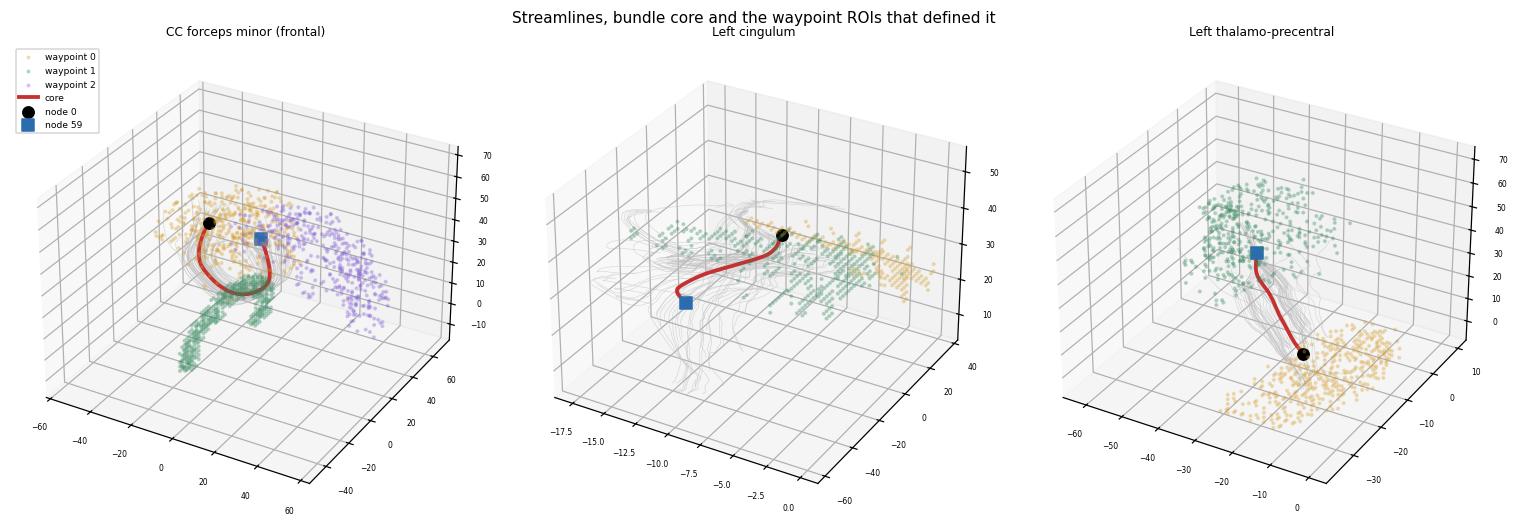

In [13]:
if PIPELINE:
    SHOW = ["cc_forceps_minor", "cingulum_l", "thalamo_prec_l"]
    fig = plt.figure(figsize=(14, 4.8))
    for s, k in enumerate(SHOW):
        oid = KEYS.index(k)
        ax = fig.add_subplot(1, len(SHOW), s + 1, projection="3d")
        for sl in BUNDLES[k]["streamlines"][::max(1, len(BUNDLES[k]["streamlines"]) // 60)]:
            a = np.asarray(sl)
            ax.plot(a[:, 0], a[:, 1], a[:, 2], lw=.4, color="0.75", alpha=.6)
        for w, ids in enumerate(BUNDLES[k]["waypoints"]):
            vox = np.argwhere(np.isin(labels_vol, ids))
            vox = vox[RNG.choice(len(vox), min(400, len(vox)), replace=False)]
            xyz = apply_affine(affine, vox)
            ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=3, alpha=.25,
                       color=["#d69e2e", "#2f855a", "#805ad5"][w % 3],
                       label=f"waypoint {w}")
        c = REF_CORE[oid]
        ax.plot(c[:, 0], c[:, 1], c[:, 2], color="#c53030", lw=2.5, label="core")
        ax.scatter(*c[0], s=55, color="black", depthshade=False, label="node 0")
        ax.scatter(*c[-1], s=55, marker="s", color="#2b6cb0", depthshade=False,
                   label=f"node {N_NODES - 1}")
        ax.set_title(BUNDLES[k]["label"], fontsize=8)
        ax.tick_params(labelsize=5)
        if s == 0:
            ax.legend(fontsize=6, loc="upper left")
    fig.suptitle("Streamlines, bundle core and the waypoint ROIs that defined it",
                 fontsize=10)
    plt.tight_layout(); plt.show()

## 4. Orientation and node correspondence

Node *i* only means anything if it means the same along-tract position on every
streamline. Three tests:

1. **orientation** -- after `orient_by_streamline`, every streamline's first point must
   be nearer to core node 0 than to the last core node;
2. **correspondence** -- the point of streamline *j* at node *i* must be nearest to
   core node *i*, not to some other node; the mean signed index offset and its spread
   measure the slippage;
3. **flip robustness** -- reversing the input direction of half the streamlines must
   not change the core or the profiles, since orientation is supposed to be resolved
   inside the pipeline rather than inherited from the tracking order.

In [14]:
if PIPELINE:
    rows = []
    for oid, k in enumerate(KEYS):
        arr, core = PTS[k], REF_CORE[oid]
        d0 = np.linalg.norm(arr[:, 0] - core[0], axis=1)
        d1 = np.linalg.norm(arr[:, 0] - core[-1], axis=1)
        oriented_ok = (d0 < d1).mean()
        # nearest core node for each (streamline, node) point
        nearest = cKDTree(core).query(arr.reshape(-1, 3), k=1)[1].reshape(arr.shape[:2])
        offset = nearest - np.arange(N_NODES)[None, :]
        arc = np.r_[0, np.cumsum(np.linalg.norm(np.diff(core, axis=0), axis=1))]
        slip_mm = np.abs(arc[nearest] - arc[np.arange(N_NODES)][None, :])
        rows.append(dict(bundle=k, oriented_fraction=oriented_ok,
                         node_offset_mean=offset.mean(),
                         node_offset_p95=np.percentile(np.abs(offset), 95),
                         slip_median_mm=np.median(slip_mm),
                         slip_p95_mm=np.percentile(slip_mm, 95),
                         core_length_mm=arc[-1],
                         exact_node_match=(offset == 0).mean()))
    orient_tab = pd.DataFrame(rows).set_index("bundle")
    display(orient_tab.round(3))
    record("all streamlines are oriented the same way as the core",
           orient_tab.oriented_fraction.min() > 0.99,
           f"min fraction with start nearer to node 0 = "
           f"{orient_tab.oriented_fraction.min():.3f}", "0.99")
    record("node i sits at along-tract position i with no systematic bias",
           abs(orient_tab.node_offset_mean).max() < 1.0,
           f"largest mean signed index offset = "
           f"{abs(orient_tab.node_offset_mean).max():.2f} nodes over all bundles -- the "
           f"correspondence is unbiased, node {N_NODES // 2} is not quietly node "
           f"{N_NODES // 2 + 3}", "|mean| < 1 node")
    # The export now ships this figure per bundle, so the check is whether the number in
    # the file is the number in the data - a documented limit, not a hidden one.
    declared = pd.Series({o["key"]: o.get("nodeResolution", {}).get("slipP95Mm", np.nan)
                          for o in GL["objects"]})
    orient_tab["declared_slip_p95_mm"] = declared
    record("the artefact declares its own along-tract resolution, and declares it right",
           bool(declared.notna().all())
           and float((orient_tab.slip_p95_mm - declared).abs().max()) < 0.5,
           f"objects[].nodeResolution.slipP95Mm is present for all {n_obj} bundles and "
           f"matches the recomputed slip to "
           f"{float((orient_tab.slip_p95_mm - declared).abs().max()):.2f} mm", "0.5 mm")
    record("a node addresses a point rather than a segment",
           orient_tab.slip_p95_mm.max() < orient_tab.core_length_mm.min() / N_NODES,
           f"no, and the export says so: streamlines slide along the core by a median of "
           f"{orient_tab.slip_median_mm.max():.1f} mm and up to "
           f"{orient_tab.slip_p95_mm.max():.1f} mm (95th percentile, "
           f"{orient_tab.node_offset_p95.max():.0f} of {N_NODES} nodes) on the worst "
           "bundle, because equal-fraction resampling makes node i the same *fraction* of "
           "every streamline rather than the same millimetre. The value at a node is a "
           "weighted average over that window, so along-tract findings belong to a local "
           "segment of the tract. `meta.spatialResolution` states this in the artefact",
           "slip < one node spacing", level="WARN")

,oriented_fraction,node_offset_mean,node_offset_p95,slip_median_mm,slip_p95_mm,core_length_mm,exact_node_match
bundle,,,,,,,
cc_forceps_minor,1.0,0.119,6.0,2.679,7.915,78.112,0.138
cc_body_motor,1.0,-0.014,6.0,3.012,9.245,86.934,0.137
cc_parietal,1.0,-0.092,6.0,3.401,9.864,97.320,0.130
cc_forceps_major,1.0,-0.130,6.0,3.996,11.640,123.487,0.166
cingulum_l,1.0,-0.306,12.0,4.357,11.696,59.226,0.071
cingulum_r,1.0,0.033,10.0,4.025,12.400,68.619,0.082
thalamo_prec_l,1.0,0.018,10.0,3.357,8.514,49.349,0.069
thalamo_prec_r,1.0,-0.076,9.0,2.973,8.974,61.544,0.094


[PASS] all streamlines are oriented the same way as the core   min fraction with start nearer to node 0 = 1.000
[PASS] node i sits at along-tract position i with no systematic bias   largest mean signed index offset = 0.31 nodes over all bundles -- the correspondence is unbiased, node 30 is not quietly node 33
[PASS] the artefact declares its own along-tract resolution, and declares it right   objects[].nodeResolution.slipP95Mm is present for all 8 bundles and matches the recomputed slip to 0.00 mm
[WARN] a node addresses a point rather than a segment   no, and the export says so: streamlines slide along the core by a median of 4.4 mm and up to 12.4 mm (95th percentile, 12 of 60 nodes) on the worst bundle, because equal-fraction resampling makes node i the same *fraction* of every streamline rather than the same millimetre. The value at a node is a weighted average over that window, so along-tract findings belong to a local segment of the tract. `meta.spatialResolution` states this in 

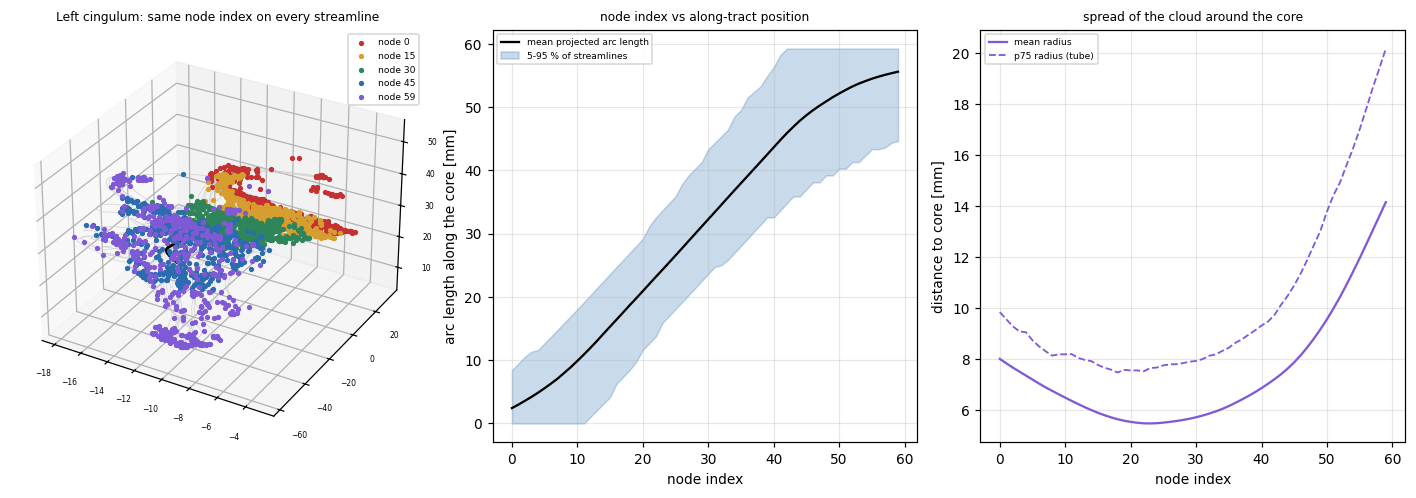

In [15]:
if PIPELINE:
    k = "cingulum_l"
    oid = KEYS.index(k)
    arr, core = PTS[k], REF_CORE[oid]
    marks = [0, 15, 30, 45, N_NODES - 1]
    mark_colors = ["#c53030", "#d69e2e", "#2f855a", "#2b6cb0", "#805ad5"]

    fig = plt.figure(figsize=(13, 4.6))
    ax = fig.add_subplot(1, 3, 1, projection="3d")
    for a in arr[::max(1, len(arr) // 60)]:
        ax.plot(a[:, 0], a[:, 1], a[:, 2], lw=.4, color="0.8")
    for m, col in zip(marks, mark_colors):
        ax.scatter(arr[:, m, 0], arr[:, m, 1], arr[:, m, 2], s=6, color=col,
                   depthshade=False, label=f"node {m}")
    ax.plot(core[:, 0], core[:, 1], core[:, 2], color="black", lw=2)
    ax.set_title(f"{BUNDLES[k]['label']}: same node index on every streamline",
                 fontsize=8)
    ax.tick_params(labelsize=5); ax.legend(fontsize=6)

    ax2 = fig.add_subplot(1, 3, 2)
    seg_core = np.r_[0, np.cumsum(np.linalg.norm(np.diff(core, axis=0), axis=1))]
    nearest = cKDTree(core).query(arr.reshape(-1, 3), k=1)[1].reshape(arr.shape[:2])
    proj = seg_core[nearest]
    ax2.plot(np.arange(N_NODES), proj.mean(axis=0), color="black", lw=1.5,
             label="mean projected arc length")
    ax2.fill_between(np.arange(N_NODES), np.percentile(proj, 5, axis=0),
                     np.percentile(proj, 95, axis=0), alpha=.25, color="#2b6cb0",
                     label="5-95 % of streamlines")
    ax2.set_xlabel("node index"); ax2.set_ylabel("arc length along the core [mm]")
    ax2.set_title("node index vs along-tract position", fontsize=8)
    ax2.legend(fontsize=6); ax2.grid(alpha=.3)

    ax3 = fig.add_subplot(1, 3, 3)
    radial = np.linalg.norm(arr - core[None], axis=2)
    ax3.plot(np.arange(N_NODES), radial.mean(axis=0), color="#805ad5", lw=1.5,
             label="mean radius")
    ax3.plot(np.arange(N_NODES), np.percentile(radial, 75, axis=0), lw=1.2, ls="--",
             color="#805ad5", label="p75 radius (tube)")
    ax3.set_xlabel("node index"); ax3.set_ylabel("distance to core [mm]")
    ax3.set_title("spread of the cloud around the core", fontsize=8)
    ax3.legend(fontsize=6); ax3.grid(alpha=.3)
    plt.tight_layout(); plt.show()

### 4.1 Flip robustness

Half the streamlines are reversed before they enter the profile step. If orientation is
genuinely resolved by `orient_by_streamline`, the core and every profile must come back
unchanged.

In [16]:
if PIPELINE:
    from dipy.tracking.streamline import Streamlines as _SL

    rows = []
    for k in ["cc_forceps_minor", "cingulum_l", "thalamo_prec_l"]:
        b = BUNDLES[k]
        sl = list(b["streamlines"])
        flip = RNG.random(len(sl)) < 0.5
        flipped = _SL([s[::-1] if f else s for s, f in zip(sl, flip)])
        b2 = dict(b, streamlines=flipped)
        prof = SRC["core_profile"](b2)
        rows.append(dict(bundle=k, flipped=int(flip.sum()),
                         max_core_shift_mm=np.abs(prof["core"] - b["core"]).max(),
                         max_FA_diff=np.abs(prof["FA"] - b["FA"]).max(),
                         max_dispersion_diff=np.abs(prof["dispersion"]
                                                    - b["dispersion"]).max()))
    flip_tab = pd.DataFrame(rows).set_index("bundle")
    display(flip_tab.round(8))
    record("reversing half the input streamlines changes nothing",
           flip_tab.max_core_shift_mm.max() < 1e-6 and flip_tab.max_FA_diff.max() < 1e-8,
           f"max core shift = {flip_tab.max_core_shift_mm.max():.2e} mm, max FA "
           f"difference = {flip_tab.max_FA_diff.max():.2e}", "1e-6 mm")

,flipped,max_core_shift_mm,max_FA_diff,max_dispersion_diff
bundle,,,,
cc_forceps_minor,1928,0.0,0.0,0.0
cingulum_l,304,0.0,0.0,0.0
thalamo_prec_l,251,0.0,0.0,0.0


[PASS] reversing half the input streamlines changes nothing   max core shift = 0.00e+00 mm, max FA difference = 0.00e+00


## 5. The weighted profiles, recomputed from the volumes

The pipeline samples the tensor volumes at the streamline points with DIPY's
`values_from_volume` and averages them with `gaussian_weights`. Here the same profile
is rebuilt with **own sampling code** -- inverse affine, then trilinear interpolation
with `scipy.ndimage.map_coordinates` -- and the weighted sum is written out explicitly:

$$\mathrm{FA}_i=\sum_j w_{ji}\,\mathrm{FA}(\mathbf x_{ji}),\qquad \sum_j w_{ji}=1$$

Two things are being tested at once: the arithmetic, and the **coordinate frame**. A
scalar volume sampled with the wrong affine would produce a smooth, plausible-looking
profile of the wrong tissue, which is why the identity-affine negative control is run
alongside.

In [17]:
if PIPELINE:
    INV = np.linalg.inv(affine)

    def sample_volume(vol, points):
        """RASMM points -> trilinear samples. Independent of dipy's implementation."""
        ijk = apply_affine(INV, np.asarray(points).reshape(-1, 3)).T
        return map_coordinates(vol.astype(float), ijk, order=1,
                               mode="nearest").reshape(np.asarray(points).shape[:-1])

    rows, weight_sums = [], []
    for oid, k in enumerate(KEYS):
        arr, w = PTS[k], WGT[k]
        weight_sums.append(np.abs(w.sum(axis=0) - 1).max())
        core_manual = np.einsum("ij,ijk->jk", w, arr)
        for c in ("FA", "AD", "RD", "MD"):
            manual = (sample_volume(SCALARS[c], arr) * w).sum(0)
            reference = REF_RAW[oid, :, CH_ALL.index(c)]
            rows.append(dict(bundle=k, channel=c,
                             max_abs_diff=np.abs(manual - reference).max(),
                             median_rel_diff=np.median(np.abs(manual - reference)
                                                       / (np.abs(reference) + 1e-12)),
                             correlation=np.corrcoef(manual, reference)[0, 1]))
        rows.append(dict(bundle=k, channel="core position [mm]",
                         max_abs_diff=np.abs(core_manual - REF_CORE[oid]).max(),
                         median_rel_diff=np.nan, correlation=np.nan))
    prof_tab = pd.DataFrame(rows)
    display(prof_tab.pivot(index="bundle", columns="channel",
                           values="max_abs_diff").round(8))

    record("the Gaussian node weights sum to 1 at every node of every bundle",
           max(weight_sums) < 1e-6,
           f"max |sum_j w_ji - 1| = {max(weight_sums):.2e}", "1e-6")
    record("the exported core is the weighted mean position, recomputed independently",
           prof_tab[prof_tab.channel == "core position [mm]"].max_abs_diff.max() < 5e-4,
           f"max displacement = "
           f"{prof_tab[prof_tab.channel == 'core position [mm]'].max_abs_diff.max():.2e} mm",
           "5e-4 mm")
    tensor_rows = prof_tab[prof_tab.channel.isin(["FA", "AD", "RD", "MD"])]
    record("FA, AD, RD and MD are the weighted means of an independent volume sampling",
           tensor_rows.median_rel_diff.max() < 0.02
           and tensor_rows.correlation.min() > 0.999,
           f"max median relative difference = {tensor_rows.median_rel_diff.max():.3%}, "
           f"min correlation = {tensor_rows.correlation.min():.6f} (residual is "
           "interpolation detail between two trilinear implementations)",
           "2 % / r > 0.999")

channel,AD,FA,MD,RD,core position [mm]
bundle,,,,,
cc_body_motor,0.0,0.0,0.0,0.0,0.0
cc_forceps_major,0.0,0.0,0.0,0.0,0.0
cc_forceps_minor,0.0,0.0,0.0,0.0,0.0
cc_parietal,0.0,0.0,0.0,0.0,0.0
cingulum_l,0.0,0.0,0.0,0.0,0.0
cingulum_r,0.0,0.0,0.0,0.0,0.0
thalamo_prec_l,0.0,0.0,0.0,0.0,0.0
thalamo_prec_r,0.0,0.0,0.0,0.0,0.0


[PASS] the Gaussian node weights sum to 1 at every node of every bundle   max |sum_j w_ji - 1| = 5.33e-15
[PASS] the exported core is the weighted mean position, recomputed independently   max displacement = 0.00e+00 mm
[PASS] FA, AD, RD and MD are the weighted means of an independent volume sampling   max median relative difference = 0.000%, min correlation = 1.000000 (residual is interpolation detail between two trilinear implementations)


### 5.1 Negative control: the affine matters

The same arithmetic with the identity affine -- i.e. treating millimetres as voxel
indices -- is what a coordinate-frame bug looks like. If that produced comparable
numbers, the agreement above would be evidence of nothing.

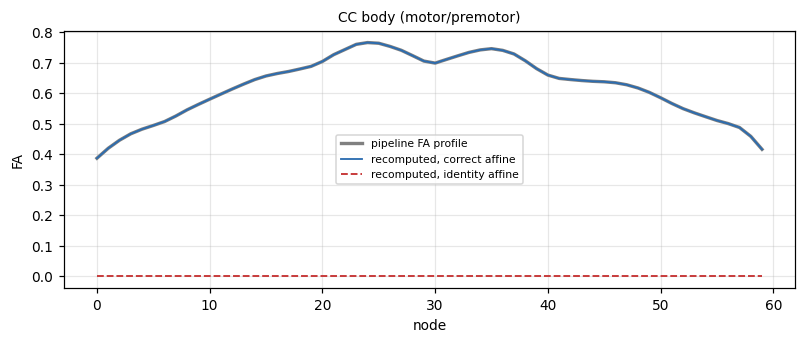

[PASS] the identity-affine control is clearly wrong, so the affine check has teeth   mean |error| with the correct affine = 3.61e-17, with the identity affine = 6.23e-01


In [18]:
if PIPELINE:
    k = "cc_body_motor"
    oid, arr, w = KEYS.index(k), PTS[k], WGT[k]
    good = (sample_volume(SCALARS["FA"], arr) * w).sum(0)
    bad = (map_coordinates(SCALARS["FA"].astype(float),
                           arr.reshape(-1, 3).T, order=1, mode="nearest")
           .reshape(arr.shape[:-1]) * w).sum(0)
    reference = REF_RAW[oid, :, CH_ALL.index("FA")]

    fig, ax = plt.subplots(figsize=(7.4, 3.2))
    ax.plot(reference, lw=2.2, color="0.5", label="pipeline FA profile")
    ax.plot(good, lw=1.2, color="#2b6cb0", label="recomputed, correct affine")
    ax.plot(bad, lw=1.2, ls="--", color="#c53030", label="recomputed, identity affine")
    ax.set_xlabel("node"); ax.set_ylabel("FA"); ax.set_title(BUNDLES[k]["label"], fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

    record("the identity-affine control is clearly wrong, so the affine check has teeth",
           np.abs(bad - reference).mean() > 20 * np.abs(good - reference).mean(),
           f"mean |error| with the correct affine = "
           f"{np.abs(good - reference).mean():.2e}, with the identity affine = "
           f"{np.abs(bad - reference).mean():.2e}")

### 5.2 Ten-node audit

Ten random (bundle, node) pairs printed end to end: exported percentile, exported raw
value, the independently recomputed weighted mean, and the value a tooltip would
recover from `meta.quantiles`.

In [19]:
QGRID = np.linspace(0, 1, 101)
QUANT = {c: np.asarray(META["quantiles"][c]) for c in CH_USE}

if PIPELINE:
    manual_cache = {(k, c): (sample_volume(SCALARS[c], PTS[k]) * WGT[k]).sum(0)
                    for k in KEYS for c in ("FA", "AD", "RD")}
rows = []
for oid, node in zip(RNG.integers(0, n_obj, 10), RNG.integers(0, N_NODES, 10)):
    k = KEYS[oid]
    row = dict(bundle=k, node=int(node), arclen_mm=REF_ARC[oid, node],
               percent=REF_PCT[node])
    for j, c in enumerate(CH_USE):
        row[f"{c}_pct"] = REF_VAL[oid, node, j]
        row[f"{c}_raw"] = REF_RAW[oid, node, CH_ALL.index(c)]
        row[f"{c}_from_quantiles"] = float(np.interp(VAL[oid, node, j], QGRID, QUANT[c]))
        if PIPELINE and c in ("FA", "AD", "RD"):
            row[f"{c}_recomputed"] = manual_cache[(k, c)][node]
    rows.append(row)
node_audit = pd.DataFrame(rows)
display(node_audit.set_index(["bundle", "node"]).T)

bundle,cc_forceps_major,thalamo_prec_r,cc_body_motor,thalamo_prec_r,cingulum_r,thalamo_prec_r,thalamo_prec_l,cingulum_l,thalamo_prec_r,cc_forceps_minor
node,13,3,0,54,32,38,58,47,14,32
arclen_mm,26.044143,3.257088,0.000000,56.619056,37.656672,40.811301,48.502235,50.509881,15.266226,42.902583
percent,22.033898,5.084746,0.000000,91.525424,54.237288,64.406780,98.305085,79.661017,23.728814,54.237288
FA_pct,0.991667,0.852083,0.008333,0.170833,0.350000,0.247917,0.075000,0.362500,0.737500,0.872917
FA_raw,0.819467,0.736465,0.387257,0.466969,0.512035,0.487155,0.425905,0.515933,0.659424,0.744110
FA_from_quantiles,0.817480,0.736485,0.385746,0.467402,0.512638,0.487300,0.426397,0.516881,0.658368,0.746464
FA_recomputed,0.819467,0.736465,0.387257,0.466969,0.512035,0.487155,0.425905,0.515933,0.659424,0.744110
AD_pct,0.958333,0.770833,0.039583,0.120833,0.429167,0.164583,0.172917,0.435417,0.581250,0.879167
AD_raw,0.001530,0.001206,0.000858,0.000896,0.000989,0.000915,0.000917,0.000992,0.001056,0.001420
AD_from_quantiles,0.001532,0.001205,0.000858,0.000897,0.000990,0.000915,0.000917,0.000992,0.001056,0.001421


## 6. Dispersion is the spread of the reconstruction, and nothing else

`dispersion` is the weighted mean distance from the bundle's own streamlines to its
core at that node, in millimetres. It is **not** fibre orientation dispersion, not axon
dispersion, not a tissue property: it describes the reconstructed streamline cloud and
therefore the tracking, seeding and clustering that produced it.

The validation is direct: recompute the mean distance from the streamline points to the
core at every node and compare it with the exported channel, then show a low-dispersion
and a high-dispersion node side by side with the point cloud that produced them.

In [20]:
if PIPELINE:
    rows = []
    for oid, k in enumerate(KEYS):
        arr, core, w = PTS[k], REF_CORE[oid], WGT[k]
        radial = np.linalg.norm(arr - core[None], axis=2)
        manual = (radial * w).sum(0)
        reference = REF_RAW[oid, :, CH_ALL.index("dispersion")]
        rows.append(dict(bundle=k,
                         max_abs_diff=np.abs(manual - reference).max(),
                         spearman_vs_unweighted_mean=spearmanr(reference,
                                                               radial.mean(0)).statistic,
                         spearman_vs_median=spearmanr(reference,
                                                      np.median(radial, 0)).statistic,
                         spearman_vs_p75=spearmanr(reference,
                                                   np.percentile(radial, 75, 0)).statistic))
    disp_tab = pd.DataFrame(rows).set_index("bundle")
    display(disp_tab.round(6))
    record("the dispersion channel is the weighted core-to-streamline distance",
           disp_tab.max_abs_diff.max() < 1e-6,
           f"max |recomputed - exported| = {disp_tab.max_abs_diff.max():.2e} mm", "1e-6 mm")
    # The bundles themselves change from run to run (section 2.1), so this statistic
    # moves too -- it has ranged over roughly 0.81-0.90 across runs of this notebook.
    # The bar is therefore set at "strong monotone agreement", not at a tight number.
    record("a longer purple fin really does mean a wider local streamline cloud",
           disp_tab.spearman_vs_unweighted_mean.min() > 0.7
           and disp_tab.spearman_vs_p75.min() > 0.6,
           f"min Spearman against the unweighted mean radius = "
           f"{disp_tab.spearman_vs_unweighted_mean.min():.3f}, against the median = "
           f"{disp_tab.spearman_vs_median.min():.3f}, against the p75 radius = "
           f"{disp_tab.spearman_vs_p75.min():.3f}. The weighting is what separates them: "
           "the exported channel deliberately discounts outlying streamlines, so it "
           f"tracks the bulk of the cloud more closely than its tail. Weakest bundle: "
           f"{disp_tab.spearman_vs_unweighted_mean.idxmin()}",
           "0.7 vs mean, 0.6 vs p75")

,max_abs_diff,spearman_vs_unweighted_mean,spearman_vs_median,spearman_vs_p75
bundle,,,,
cc_forceps_minor,0.0,0.955932,0.968158,0.958989
cc_body_motor,0.0,0.994387,0.996277,0.993832
cc_parietal,0.0,0.993832,0.992276,0.990442
cc_forceps_major,0.0,0.848236,0.730092,0.846291
cingulum_l,0.0,0.968436,0.967824,0.983996
cingulum_r,0.0,0.982384,0.989664,0.968880
thalamo_prec_l,0.0,0.958433,0.984218,0.958322
thalamo_prec_r,0.0,0.989775,0.972326,0.959044


[PASS] the dispersion channel is the weighted core-to-streamline distance   max |recomputed - exported| = 0.00e+00 mm
[PASS] a longer purple fin really does mean a wider local streamline cloud   min Spearman against the unweighted mean radius = 0.848, against the median = 0.730, against the p75 radius = 0.846. The weighting is what separates them: the exported channel deliberately discounts outlying streamlines, so it tracks the bulk of the cloud more closely than its tail. Weakest bundle: cc_forceps_major


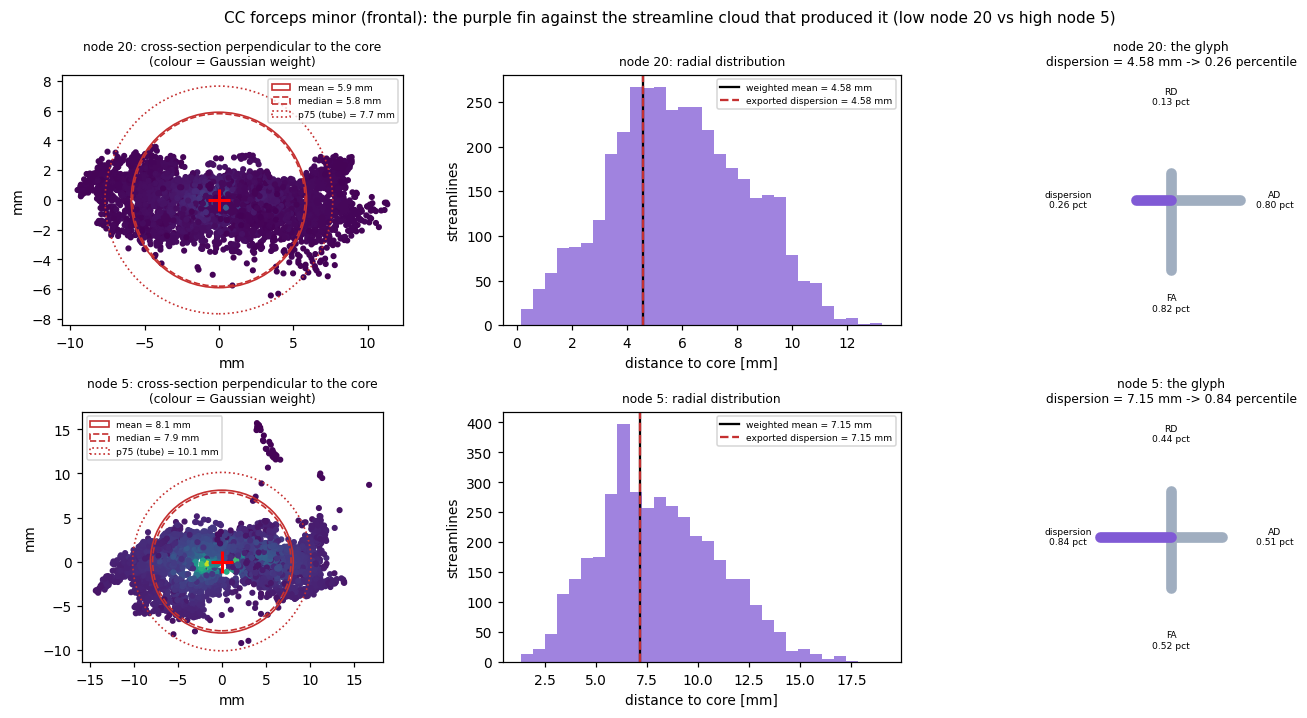

In [21]:
if PIPELINE:
    k = "cc_forceps_minor"
    oid = KEYS.index(k)
    arr, core = PTS[k], REF_CORE[oid]
    disp = REF_RAW[oid, :, CH_ALL.index("dispersion")]
    lo, hi = int(np.argmin(disp[5:-5]) + 5), int(np.argmax(disp[5:-5]) + 5)

    fig, axes = plt.subplots(2, 3, figsize=(13, 6.6))
    for r, node in enumerate([lo, hi]):
        t = core[min(node + 1, N_NODES - 1)] - core[max(node - 1, 0)]
        t /= np.linalg.norm(t) + 1e-12
        ref = np.array([0., 0., 1.]) if abs(t[2]) < 0.9 else np.array([1., 0., 0.])
        n1 = np.cross(t, ref); n1 /= np.linalg.norm(n1)
        n2 = np.cross(t, n1)
        rel = arr[:, node] - core[node]
        u, v = rel @ n1, rel @ n2
        d = np.linalg.norm(rel, axis=1)
        w = WGT[k][:, node]

        ax = axes[r, 0]
        ax.scatter(u, v, s=9, c=w, cmap="viridis")
        ax.plot(0, 0, "r+", ms=14, mew=2)
        for rad, ls, lab in [(d.mean(), "-", "mean"), (np.median(d), "--", "median"),
                             (np.percentile(d, 75), ":", "p75 (tube)")]:
            ax.add_patch(plt.Circle((0, 0), rad, fill=False, ls=ls, color="#c53030",
                                    lw=1.1, label=f"{lab} = {rad:.1f} mm"))
        ax.set_aspect("equal"); ax.legend(fontsize=6)
        ax.set_title(f"node {node}: cross-section perpendicular to the core\n"
                     f"(colour = Gaussian weight)", fontsize=8)
        ax.set_xlabel("mm"); ax.set_ylabel("mm")

        ax = axes[r, 1]
        ax.hist(d, bins=30, color="#805ad5", alpha=.75)
        ax.axvline((d * w).sum() / w.sum(), color="black", lw=1.5,
                   label=f"weighted mean = {(d * w).sum() / w.sum():.2f} mm")
        ax.axvline(disp[node], color="#c53030", ls="--", lw=1.5,
                   label=f"exported dispersion = {disp[node]:.2f} mm")
        ax.set_xlabel("distance to core [mm]"); ax.set_ylabel("streamlines")
        ax.legend(fontsize=6); ax.set_title(f"node {node}: radial distribution", fontsize=8)

        ax = axes[r, 2]
        ang = np.linspace(0, 2 * np.pi, len(CH_USE), endpoint=False) - np.pi / 2
        for a_, val, name in zip(ang, REF_VAL[oid, node], CH_USE):
            ax.plot([0, np.cos(a_) * (0.3 + val)], [0, np.sin(a_) * (0.3 + val)],
                    lw=7, solid_capstyle="round",
                    color="#805ad5" if name == "dispersion" else "#a0aec0")
            ax.text(np.cos(a_) * 1.65, np.sin(a_) * 1.65,
                    f"{name}\n{val:.2f} pct", ha="center", va="center", fontsize=6)
        ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_aspect("equal"); ax.axis("off")
        ax.set_title(f"node {node}: the glyph\ndispersion = {disp[node]:.2f} mm "
                     f"-> {REF_VAL[oid, node, CH_USE.index('dispersion')]:.2f} percentile",
                     fontsize=8)
    fig.suptitle(f"{BUNDLES[k]['label']}: the purple fin against the streamline cloud "
                 f"that produced it (low node {lo} vs high node {hi})", fontsize=10)
    plt.tight_layout(); plt.show()

## 7. The glyph node and the profile node are the same node

A linked view: pick a node in 3D, and the vertical line in the profile panel must land
on the values that node's fins encode. Ten random nodes are checked numerically first,
then the alternatives are scored -- a one-node shift, a reversed node order, and a
whole-bundle offset -- so that "aligned" means "aligned and nothing else is".

In [22]:
def hypothesis_score(name, block):
    ranks = np.column_stack([RANKF(rankdata(block.reshape(-1, len(CH_USE))[:, j]))
                             for j in range(len(CH_USE))]).reshape(VAL.shape)
    err = np.abs(ranks - VAL)
    return dict(hypothesis=name, nodes_disagreeing=int((err > TOLS).sum()),
                agreement=1 - (err > TOLS).mean(), median_err=np.median(err))


alt_rows = [
    hypothesis_score("accepted: node i -> node i", RAW_USE),
    hypothesis_score("profile shifted by +1 node",
                     RAW_USE[:, np.r_[np.arange(1, N_NODES), N_NODES - 1], :]),
    hypothesis_score("profile shifted by -1 node",
                     RAW_USE[:, np.r_[0, np.arange(N_NODES - 1)], :]),
    hypothesis_score("node order reversed", RAW_USE[:, ::-1, :]),
    hypothesis_score("values taken from the next bundle", np.roll(RAW_USE, 1, axis=0)),
]
alt = pd.DataFrame(alt_rows).set_index("hypothesis")
display(alt.round(6))
best = alt.nodes_disagreeing.idxmin()
runner_up = alt.nodes_disagreeing.drop(best).min()
record("node-to-profile alignment is the unique explanation of the exported values",
       best.startswith("accepted") and alt.nodes_disagreeing.min() == 0
       and runner_up > 0.5 * n_total * len(CH_USE),
       f"the accepted mapping explains every one of the {n_total * len(CH_USE)} exported "
       f"values; the next best hypothesis leaves {runner_up} of them unexplained")

,nodes_disagreeing,agreement,median_err
hypothesis,,,
accepted: node i -> node i,0,1.000000,0.000033
profile shifted by +1 node,1881,0.020312,0.020800
profile shifted by -1 node,1880,0.020833,0.020783
node order reversed,1920,0.000000,0.102050
values taken from the next bundle,1920,0.000000,0.179150


[PASS] node-to-profile alignment is the unique explanation of the exported values   the accepted mapping explains every one of the 1920 exported values; the next best hypothesis leaves 1880 of them unexplained


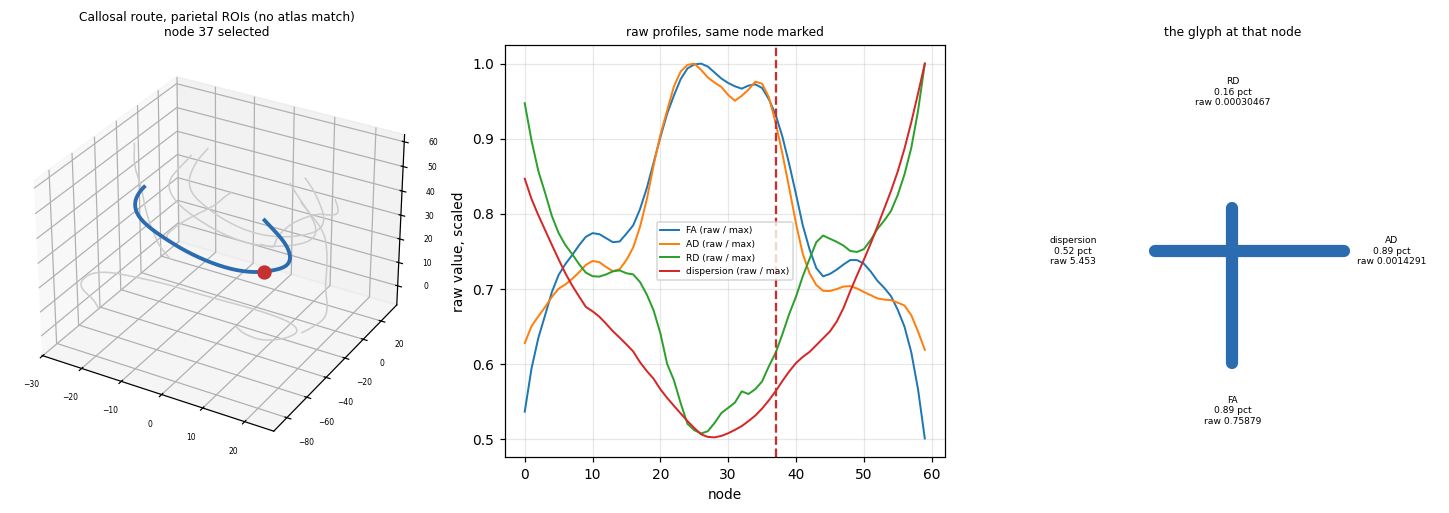

In [23]:
k = "cc_parietal"
oid = KEYS.index(k)
node = 37
fig = plt.figure(figsize=(13.5, 4.6))
ax = fig.add_subplot(1, 3, 1, projection="3d")
for j, key in enumerate(KEYS):
    c = CORE[j]
    ax.plot(c[:, 0], c[:, 1], c[:, 2], lw=1, color="0.8")
c = CORE[oid]
ax.plot(c[:, 0], c[:, 1], c[:, 2], lw=2.5, color="#2b6cb0")
ax.scatter(*c[node], s=70, color="#c53030", depthshade=False)
ax.set_title(f"{GL['objects'][oid]['label']}\nnode {node} selected", fontsize=8)
ax.tick_params(labelsize=5)

ax2 = fig.add_subplot(1, 3, 2)
for j, ch in enumerate(CH_USE):
    raw = RAWJ[oid, :, CH_ALL.index(ch)]
    ax2.plot(np.arange(N_NODES), raw / raw.max(), lw=1.3, label=f"{ch} (raw / max)")
ax2.axvline(node, color="#c53030", lw=1.5, ls="--")
ax2.set_xlabel("node"); ax2.set_ylabel("raw value, scaled")
ax2.set_title("raw profiles, same node marked", fontsize=8)
ax2.legend(fontsize=6); ax2.grid(alpha=.3)

ax3 = fig.add_subplot(1, 3, 3)
ang = np.linspace(0, 2 * np.pi, len(CH_USE), endpoint=False) - np.pi / 2
for a_, val, ch in zip(ang, VAL[oid, node], CH_USE):
    ax3.plot([0, np.cos(a_) * (0.3 + val)], [0, np.sin(a_) * (0.3 + val)], lw=8,
             solid_capstyle="round", color="#2b6cb0")
    ax3.text(np.cos(a_) * 1.7, np.sin(a_) * 1.7,
             f"{ch}\n{val:.2f} pct\nraw {RAWJ[oid, node, CH_ALL.index(ch)]:.5g}",
             ha="center", va="center", fontsize=6)
ax3.set_xlim(-2.2, 2.2); ax3.set_ylim(-2.2, 2.2); ax3.set_aspect("equal"); ax3.axis("off")
ax3.set_title("the glyph at that node", fontsize=8)
plt.tight_layout(); plt.show()

## 8. Normalisation

Same four questions as in the turbulence case: order preserving, per channel, over
which pool, and invertible.

,inversions_beyond_rounding,ties_from_raw_write_precision,max_deviation_from_rank_grid,n_zero_raw,n_tied_raw,max_diff_if_pooled_per_bundle,quantile_roundtrip_median_rel_err,quantile_roundtrip_p95_rel_err
channel,,,,,,,,
FA,0,0,0.0001,0,0,0.593800,0.000882,0.003775
AD,0,2,0.0001,0,2,0.622900,0.000599,0.004080
RD,0,3,0.0001,0,3,0.581233,0.000649,0.005878
dispersion,0,0,0.0001,0,0,0.560433,0.001182,0.009798


[PASS] normalisation is order preserving within every channel   no pair of nodes is stored out of raw order by more than the 4-decimal write precision
[PASS] each channel is ranked separately over all exported nodes   each channel's 480 values are a permutation of the rank grid to within 1.00e-04 (half a rank step is 1.04e-03, reached only where raw values tie at the write precision)
[PASS] the pool is all bundles together, not each bundle on its own   per-bundle ranking would differ by up to 0.62 in percentile -- so a fin compares a node against every other bundle's nodes, which is what the legend must say
[PASS] meta.quantiles inverts a percentile back to a physical value   median relative error 0.12%, p95 0.98%


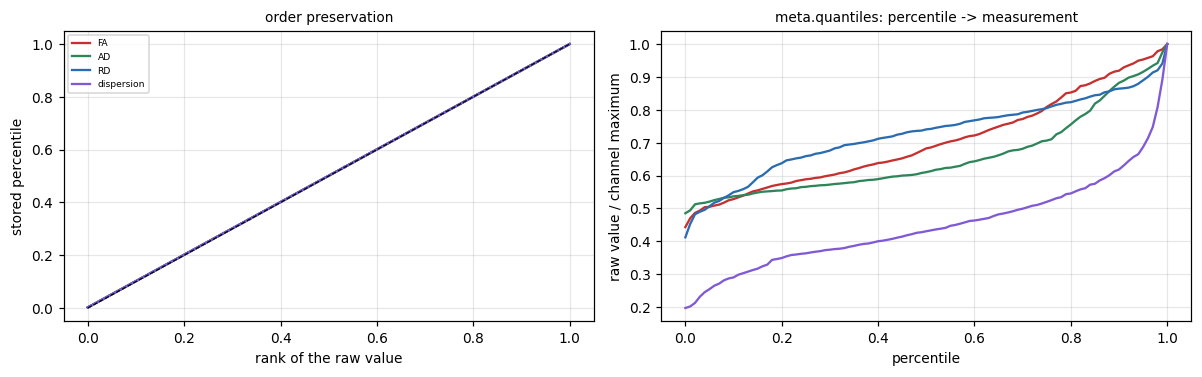

Legend wording implied by these results:
  FA          -> 'FA percentile' (rank among 480 nodes of 8 bundles; raw unit: fractional anisotropy (dimensionless, 0-1))
  AD          -> 'AD percentile' (rank among 480 nodes of 8 bundles; raw unit: axial diffusivity (mm^2/s))
  RD          -> 'RD percentile' (rank among 480 nodes of 8 bundles; raw unit: radial diffusivity (mm^2/s))
  dispersion  -> 'Bundle dispersion percentile' (rank among 480 nodes of 8 bundles; raw unit: weighted mean distance to the bundle core (mm))


In [24]:
rows = []
grid = RANKF(np.arange(n_total) + 1.0)
for j, c in enumerate(CH_USE):
    v = VAL[..., j].ravel()
    raw = RAW_USE[..., j].ravel()
    order = np.argsort(raw, kind="stable")
    per_bundle = np.concatenate([rankdata(RAW_USE[o, :, j]) / N_NODES
                                 for o in range(n_obj)])
    recov = np.interp(v, QGRID, QUANT[c])
    rel = np.abs(recov - raw) / (np.abs(raw) + 1e-30)
    # raw_values are written with 8 decimals, so two nodes can share a stored raw value
    # while their ranks came from values that differed further down. Those pairs are the
    # write precision, not an ordering error, and are excluded from the inversion count.
    dv, draw = np.diff(v[order]), np.diff(raw[order])
    rows.append(dict(channel=c,
                     inversions_beyond_rounding=int(((dv < -TOL_ROUND)
                                                     & (draw > TOL_RAW)).sum()),
                     ties_from_raw_write_precision=int((draw <= TOL_RAW).sum()),
                     max_deviation_from_rank_grid=np.abs(np.sort(v)
                                                         - np.round(grid, 4)).max(),
                     n_zero_raw=int((raw == 0).sum()),
                     n_tied_raw=int(len(raw) - len(np.unique(raw))),
                     max_diff_if_pooled_per_bundle=np.abs(v - per_bundle).max(),
                     quantile_roundtrip_median_rel_err=np.median(rel),
                     quantile_roundtrip_p95_rel_err=np.percentile(rel, 95)))
norm_tab = pd.DataFrame(rows).set_index("channel")
display(norm_tab.round(6))

record("normalisation is order preserving within every channel",
       int(norm_tab.inversions_beyond_rounding.max()) == 0,
       "no pair of nodes is stored out of raw order by more than the 4-decimal write "
       "precision", TOL_ROUND)
record("each channel is ranked separately over all exported nodes",
       norm_tab.max_deviation_from_rank_grid.max() <= 0.5 / n_total + TOL_ROUND,
       f"each channel's {n_total} values are a permutation of the rank grid to within "
       f"{norm_tab.max_deviation_from_rank_grid.max():.2e} (half a rank step is "
       f"{0.5 / n_total:.2e}, reached only where raw values tie at the write "
       "precision)", "half a rank step")
record("the pool is all bundles together, not each bundle on its own",
       norm_tab.max_diff_if_pooled_per_bundle.max() > 0.1,
       f"per-bundle ranking would differ by up to "
       f"{norm_tab.max_diff_if_pooled_per_bundle.max():.2f} in percentile -- so a fin "
       "compares a node against every other bundle's nodes, which is what the legend "
       "must say")
record("meta.quantiles inverts a percentile back to a physical value",
       norm_tab.quantile_roundtrip_median_rel_err.max() < 0.05,
       f"median relative error {norm_tab.quantile_roundtrip_median_rel_err.max():.2%}, "
       f"p95 {norm_tab.quantile_roundtrip_p95_rel_err.max():.2%}", "5 % median")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
cols = ["#c53030", "#2f855a", "#2b6cb0", "#805ad5"]
for j, c in enumerate(CH_USE):
    o = np.argsort(RAW_USE[..., j].ravel())
    ax[0].plot(np.linspace(0, 1, n_total), VAL[..., j].ravel()[o], lw=1.5, color=cols[j],
               label=c)
    ax[1].plot(QGRID, QUANT[c] / QUANT[c][-1], lw=1.5, color=cols[j], label=c)
ax[0].plot([0, 1], [0, 1], "k--", lw=.8)
ax[0].set_xlabel("rank of the raw value"); ax[0].set_ylabel("stored percentile")
ax[0].set_title("order preservation", fontsize=9); ax[0].legend(fontsize=6)
ax[1].set_xlabel("percentile"); ax[1].set_ylabel("raw value / channel maximum")
ax[1].set_title("meta.quantiles: percentile -> measurement", fontsize=9)
for a_ in ax:
    a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Legend wording implied by these results:")
for c in CH_USE:
    print(f"  {c:11s} -> '{META['channelInfo'][c]['label']}' "
          f"(rank among {n_total} nodes of {n_obj} bundles; raw unit: "
          f"{META['channelInfo'][c]['raw']})")

## 9. How much would a rebuild move this?

The artefact is now pinned to a fixed set of streamlines, so the question "is the export
reproducible" has been answered by construction: section 2.2 regenerates it exactly. The
question that remains is different and still matters -- **if the whole pipeline were run
again from the DWI, how far would these bundles move?** That is the uncertainty a reader
inherits when they take a figure from this case as a statement about the brain rather
than about one reconstruction.

Two sources are separated:

* **rebuild spread** -- the same code, the same parameters, a new tractogram. Because
  `deterministic_tracking` is not reproducible, this is not zero, and it is the floor
  under everything else.
* **parameter effects** -- clustering threshold, MDF radius, ROI dilation, node count,
  and a streamline subsample. Anything smaller than the rebuild spread has not been
  shown to be an effect at all.

Both are measured against the persisted reconstruction, after resampling to `N_NODES`.
The variant is flipped if that fits better -- and with the anatomical orientation now in
place, `flipped` should stay `False` everywhere, which is itself the test of that fix.

In [25]:
SENS_BUNDLES = ["cc_forceps_minor", "cingulum_l", "thalamo_prec_l"]
EDGE = 5   # nodes excluded at each end when locating a profile extremum

if PIPELINE:
    from dipy.data import default_sphere
    from dipy.direction import peaks_from_model
    from dipy.reconst.shm import CsaOdfModel
    from dipy.segment.clustering import QuickBundles
    from dipy.segment.featurespeed import ResampleFeature
    from dipy.segment.metric import AveragePointwiseEuclideanMetric
    from dipy.tracking import utils
    from dipy.tracking.stopping_criterion import ThresholdStoppingCriterion
    from dipy.tracking.streamline import Streamlines as _SL2
    from dipy.tracking.tracker import deterministic_tracking

    SPECS = {sp["key"]: sp for sp in SRC["BUNDLE_SPECS"]}
    base_roi_mask = SRC["roi_mask"]
    NODE_MM = {k: float(np.linalg.norm(np.diff(REF_CORE[KEYS.index(k)], axis=0), axis=1).sum()
                        / (N_NODES - 1)) for k in KEYS}

    def rebuild_qb():
        SRC["qb"] = QuickBundles(
            threshold=SRC["QB_THRESHOLD"],
            metric=AveragePointwiseEuclideanMetric(
                ResampleFeature(nb_points=SRC["N_NODES"])))

    def resample_profile(values, n_out=N_NODES):
        x = np.linspace(0, 1, len(values))
        return np.interp(np.linspace(0, 1, n_out), x, np.asarray(values))

    def extremum_percent(values, how="max"):
        v = values[EDGE:N_NODES - EDGE]
        i = int(np.argmax(v) if how == "max" else np.argmin(v)) + EDGE
        return 100.0 * i / (N_NODES - 1)

    def variant_metrics(key, bundle, tag):
        """Compare a variant against the persisted reconstruction. `flipped` records
        whether the variant had to be reversed to line up -- with the waypoint-anchored
        orientation it should never be True."""
        oid = KEYS.index(key)
        if bundle is None:
            return dict(bundle=key, variant=tag, kept=0, flipped=False,
                        mean_core_shift_mm=np.nan, max_core_shift_mm=np.nan,
                        shift_in_nodes=np.nan, FA_min_pct=np.nan, RD_max_pct=np.nan,
                        disp_max_pct=np.nan, FA_spearman=np.nan, disp_spearman=np.nan)
        core = np.stack([resample_profile(bundle["core"][:, d]) for d in range(3)], axis=1)
        flipped = (np.linalg.norm(core[::-1] - REF_CORE[oid], axis=1).mean()
                   < np.linalg.norm(core - REF_CORE[oid], axis=1).mean())
        order = slice(None, None, -1) if flipped else slice(None)
        core = core[order]
        shift = np.linalg.norm(core - REF_CORE[oid], axis=1)
        fa = resample_profile(bundle["FA"])[order]
        rd = resample_profile(bundle["RD"])[order]
        dp = resample_profile(bundle["dispersion"])[order]
        return dict(bundle=key, variant=tag, kept=int(bundle["n_streamlines"]),
                    flipped=bool(flipped),
                    mean_core_shift_mm=shift.mean(), max_core_shift_mm=shift.max(),
                    shift_in_nodes=shift.max() / NODE_MM[key],
                    FA_min_pct=extremum_percent(fa, "min"),
                    RD_max_pct=extremum_percent(rd),
                    disp_max_pct=extremum_percent(dp),
                    FA_spearman=spearmanr(fa, REF_RAW[oid, :, i_fa]).statistic,
                    disp_spearman=spearmanr(dp, REF_RAW[oid, :, i_disp]).statistic)

    def extract_and_profile(key):
        b, _ = SRC["extract_bundle"](SPECS[key])
        if b is not None:
            b.update(SRC["core_profile"](b))
            b["n_streamlines"] = len(b["streamlines"])
        return b

    def run_variant(tag, **params):
        saved = {k: SRC[k] for k in params}
        SRC.update(params)
        if "ROI_DILATION" in params:
            d = params["ROI_DILATION"]
            SRC["roi_mask"] = lambda ids, dilation=d: base_roi_mask(ids, dilation)
        rebuild_qb()
        out = [variant_metrics(key, extract_and_profile(key), tag) for key in SENS_BUNDLES]
        SRC.update(saved)
        SRC["roi_mask"] = base_roi_mask
        rebuild_qb()
        return out

    CSA_PEAKS = None

    def track_once(seed_density=None, gfa=None, seed=42):
        """One fresh whole-brain tractogram with the producing notebook's parameters."""
        global CSA_PEAKS
        if CSA_PEAKS is None:
            CSA_PEAKS = peaks_from_model(
                CsaOdfModel(SRC["gtab"], sh_order_max=6), SRC["data"], default_sphere,
                relative_peak_threshold=0.8, min_separation_angle=45,
                mask=SRC["white_matter"], npeaks=3, return_sh=True, normalize_peaks=True)
        stopping = ThresholdStoppingCriterion(
            CSA_PEAKS.gfa, SRC["GFA_THRESHOLD"] if gfa is None else gfa)
        seeds = utils.seeds_from_mask(
            SRC["white_matter"], SRC["affine"],
            density=SRC["SEED_DENSITY"] if seed_density is None else seed_density)
        tg = deterministic_tracking(seeds, stopping, SRC["affine"], sh=CSA_PEAKS.shm_coeff,
                                    sphere=default_sphere, max_angle=SRC["MAX_ANGLE"],
                                    step_size=SRC["STEP_SIZE"], min_len=20, max_len=400,
                                    random_seed=seed)
        return _SL2(tg)

### 9.1 Rebuild spread

Two fresh tractograms, the same parameters, the same seed. Everything downstream is
rebuilt from each and compared with the persisted reconstruction.

In [26]:
rebuild_rows = []
if PIPELINE and RETRACK:
    for tag in ["rebuild A", "rebuild B"]:
        t0 = time.time()
        SRC["STREAMLINES"] = track_once()
        rebuild_rows += [variant_metrics(key, extract_and_profile(key), tag)
                         for key in SENS_BUNDLES]
        print(f"  {tag}: {len(SRC['STREAMLINES']):,} whole-brain streamlines, "
              f"{time.time() - t0:.0f} s")
    rebuild_tab = pd.DataFrame(rebuild_rows)
    display(rebuild_tab.set_index(["bundle", "variant"]).round(3))

    record("the along-tract direction survives a rebuild",
           not bool(rebuild_tab.flipped.any()),
           f"0/{len(rebuild_tab)} rebuilt bundles had to be reversed to line up with the "
           "export; the waypoint-anchored orientation holds across tractograms, where "
           "the QuickBundles direction previously flipped 2-4 of 8 bundles")
elif PIPELINE:
    print("RETRACK = False: the rebuild spread was not measured, so nothing in 9.2 can "
          "be called a parameter effect rather than tracking variability.")

  rebuild A: 296,838 whole-brain streamlines, 78 s


  rebuild B: 294,792 whole-brain streamlines, 70 s


,,kept,flipped,mean_core_shift_mm,max_core_shift_mm,shift_in_nodes,FA_min_pct,RD_max_pct,disp_max_pct,FA_spearman,disp_spearman
bundle,variant,,,,,,,,,,
cc_forceps_minor,rebuild A,3511,False,0.230,0.292,0.221,77.966,10.169,8.475,0.998,0.991
cingulum_l,rebuild A,549,False,0.599,2.262,2.254,8.475,8.475,91.525,0.999,0.991
thalamo_prec_l,rebuild A,463,False,0.841,1.101,1.316,71.186,91.525,91.525,0.989,0.967
cc_forceps_minor,rebuild B,3262,False,0.319,0.503,0.380,77.966,77.966,8.475,0.998,0.997
cingulum_l,rebuild B,530,False,5.040,10.200,10.161,91.525,91.525,91.525,0.970,0.678
thalamo_prec_l,rebuild B,369,False,1.508,2.433,2.909,76.271,76.271,91.525,0.971,0.949


[PASS] the along-tract direction survives a rebuild   0/6 rebuilt bundles had to be reversed to line up with the export; the waypoint-anchored orientation holds across tractograms, where the QuickBundles direction previously flipped 2-4 of 8 bundles


### 9.2 Bundle-definition parameters

These re-use the tractogram from the last rebuild, so they isolate the waypoint and
clustering step. The streamline subsamples need no tractogram at all -- they resample the
persisted bundles -- so they run either way.

In [27]:
if PIPELINE:
    rows = [variant_metrics(k, BUNDLES[k], "persisted (baseline)") for k in SENS_BUNDLES]

    if RETRACK:
        VARIANTS = [
            ("QuickBundles 6 mm", dict(QB_THRESHOLD=6.0)),
            ("QuickBundles 10 mm", dict(QB_THRESHOLD=10.0)),
            ("MDF radius 9 mm", dict(MDF_RADIUS_MM=9.0)),
            ("MDF radius 15 mm", dict(MDF_RADIUS_MM=15.0)),
            ("ROI dilation 1 voxel", dict(ROI_DILATION=1)),
            ("ROI dilation 3 voxels", dict(ROI_DILATION=3)),
            ("40 nodes", dict(N_NODES=40)),
            ("80 nodes", dict(N_NODES=80)),
        ]
        for tag, params in VARIANTS:
            t0 = time.time()
            rows += run_variant(tag, **params)
            print(f"  {tag:24s} {time.time() - t0:6.1f} s")

    for rep in range(3):
        for key in SENS_BUNDLES:
            sl = list(BUNDLES[key]["streamlines"])
            take = RNG.choice(len(sl), len(sl) // 2, replace=False)
            b = dict(BUNDLES[key], streamlines=_SL2([sl[i] for i in take]))
            b.update(SRC["core_profile"](b))
            b["n_streamlines"] = len(take)
            rows.append(variant_metrics(key, b, f"50 % streamline subsample #{rep + 1}"))

    sens = pd.DataFrame(rows + rebuild_rows)
    display(sens.set_index(["bundle", "variant"]).round(3))

  QuickBundles 6 mm          13.3 s


  QuickBundles 10 mm         13.7 s


  MDF radius 9 mm            12.3 s


  MDF radius 15 mm           14.3 s


  ROI dilation 1 voxel       11.2 s


  ROI dilation 3 voxels      14.5 s


  40 nodes                   12.2 s


  80 nodes                   14.8 s


,,kept,flipped,mean_core_shift_mm,max_core_shift_mm,shift_in_nodes,FA_min_pct,RD_max_pct,disp_max_pct,FA_spearman,disp_spearman
bundle,variant,,,,,,,,,,
cc_forceps_minor,persisted (baseline),3833,False,0.000,0.000,0.000,77.966,77.966,8.475,1.000,1.000
cingulum_l,persisted (baseline),586,False,0.000,0.000,0.000,8.475,8.475,91.525,1.000,1.000
thalamo_prec_l,persisted (baseline),482,False,0.000,0.000,0.000,74.576,74.576,91.525,1.000,1.000
cc_forceps_minor,QuickBundles 6 mm,2654,False,47.226,66.203,50.005,91.525,91.525,8.475,0.850,0.933
cingulum_l,QuickBundles 6 mm,717,False,6.115,7.911,7.880,91.525,91.525,8.475,0.930,0.790
thalamo_prec_l,QuickBundles 6 mm,361,False,1.627,2.589,3.095,76.271,76.271,91.525,0.965,0.939
cc_forceps_minor,QuickBundles 10 mm,3408,False,0.782,1.063,0.803,77.966,77.966,8.475,0.998,0.999
cingulum_l,QuickBundles 10 mm,606,False,8.248,8.728,8.695,8.475,8.475,8.475,0.774,0.377
thalamo_prec_l,QuickBundles 10 mm,358,False,14.229,18.089,21.627,57.627,57.627,91.525,0.597,0.181


### 9.3 What the numbers support

The comparison that matters is not against an arbitrary millimetre threshold. The export
already declares its own along-tract resolution -- `nodeResolution.slipP95Mm`, the
distance individual streamlines slide along the core, a few to ~12 mm depending on the
bundle. A rebuild that moves the core by less than that adds no new uncertainty; a
rebuild that moves it by more makes the rebuild, not the resampling, the limiting factor.
Both statements are made per bundle, because the bundles differ by an order of magnitude.

,worst_core_shift_mm,worst_FA_spearman,flips,node_spacing_mm,declared_slip_p95_mm,rebuild_shift_mm,rebuild_over_declared
bundle,,,,,,,
cc_forceps_minor,66.44,0.85,0,1.32,7.92,0.50,0.06
cingulum_l,16.97,0.72,0,1.00,11.70,10.20,0.87
thalamo_prec_l,18.09,0.60,0,0.84,8.51,2.43,0.29


,max_core_shift_mm,max_shift_in_nodes,min_FA_spearman,min_disp_spearman,flips
variant,,,,,
40 nodes,11.61,11.56,0.72,0.61,0
50 % streamline subsample #1,0.80,0.96,0.99,0.98,0
50 % streamline subsample #2,0.96,1.15,0.99,0.99,0
50 % streamline subsample #3,0.62,0.72,0.99,0.99,0
80 nodes,3.33,3.31,0.97,0.95,0
MDF radius 15 mm,6.99,6.97,0.97,0.62,0
MDF radius 9 mm,16.97,16.91,0.77,0.41,0
QuickBundles 10 mm,18.09,21.63,0.60,0.18,0
QuickBundles 6 mm,66.20,50.01,0.85,0.79,0


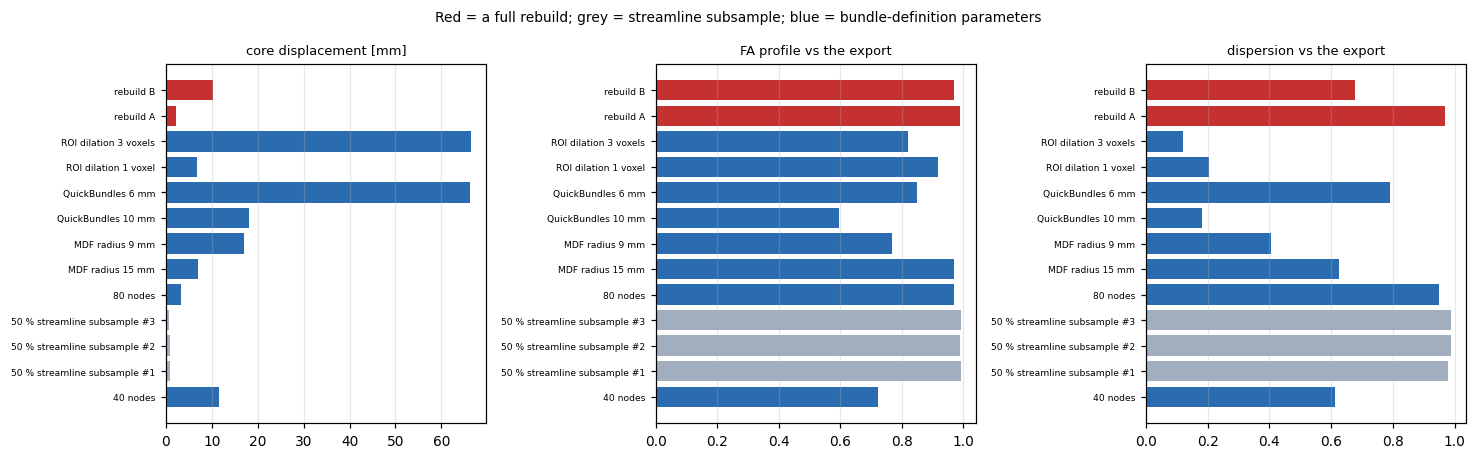

[PASS] a rebuild stays inside the along-tract resolution the export declares   cc_forceps_minor: rebuild 0.5 mm vs declared 7.9 mm; cingulum_l: rebuild 10.2 mm vs declared 11.7 mm; thalamo_prec_l: rebuild 2.4 mm vs declared 8.5 mm. Where the ratio exceeds 1 the rebuild, not the resampling, sets the spatial resolution of any claim about that bundle
[PASS] any parameter choice moves a bundle further than simply rebuilding it does   16 of 39 variant-bundle pairs exceed their own rebuild spread (worst: ROI dilation 3 voxels on cc_forceps_minor, 132.1x)

How to read this section, in one sentence per row of the table above:

  * `rebuild_shift_mm` is what a *new* run of the whole pipeline would do to this bundle.
  * `declared_slip_p95_mm` is the along-tract resolution the export already admits to.
  * Their ratio says which of the two limits an along-tract statement. For the compact
    bundles both are a few millimetres; for the callosal fan the rebuild dominates, and a
    figure caption 

In [28]:
if PIPELINE:
    slip95 = {o["key"]: o["points"][0]["attributes"].get("nodeSlipP95Mm",
              GL["objects"][i].get("nodeResolution", {}).get("slipP95Mm", np.nan))
              for i, o in enumerate(GL["objects"])}
    var = sens[sens.variant != "persisted (baseline)"]
    per_bundle = var.groupby("bundle").agg(
        worst_core_shift_mm=("max_core_shift_mm", "max"),
        worst_FA_spearman=("FA_spearman", "min"),
        flips=("flipped", "sum"))
    per_bundle["node_spacing_mm"] = [NODE_MM[b] for b in per_bundle.index]
    per_bundle["declared_slip_p95_mm"] = [slip95[b] for b in per_bundle.index]
    if rebuild_rows:
        rb = pd.DataFrame(rebuild_rows).groupby("bundle").max_core_shift_mm.max()
        per_bundle["rebuild_shift_mm"] = rb
        per_bundle["rebuild_over_declared"] = (per_bundle.rebuild_shift_mm
                                               / per_bundle.declared_slip_p95_mm)
    display(per_bundle.round(2))

    summary = var.groupby("variant").agg(
        max_core_shift_mm=("max_core_shift_mm", "max"),
        max_shift_in_nodes=("shift_in_nodes", "max"),
        min_FA_spearman=("FA_spearman", "min"),
        min_disp_spearman=("disp_spearman", "min"),
        flips=("flipped", "sum"))
    display(summary.round(2))

    fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))
    colors = ["#c53030" if "rebuild" in v else
              "#a0aec0" if "subsample" in v else "#2b6cb0" for v in summary.index]
    for a_, (col, ttl) in zip(ax, [("max_core_shift_mm", "core displacement [mm]"),
                                   ("min_FA_spearman", "FA profile vs the export"),
                                   ("min_disp_spearman", "dispersion vs the export")]):
        a_.barh(range(len(summary)), summary[col], color=colors)
        a_.set_yticks(range(len(summary))); a_.set_yticklabels(summary.index, fontsize=6)
        a_.set_title(ttl, fontsize=8.5); a_.grid(alpha=.3, axis="x")
    fig.suptitle("Red = a full rebuild; grey = streamline subsample; "
                 "blue = bundle-definition parameters", fontsize=9)
    plt.tight_layout(); plt.show()

    if rebuild_rows:
        within = per_bundle[per_bundle.rebuild_over_declared <= 1.0]
        record("a rebuild stays inside the along-tract resolution the export declares",
               len(within) == len(per_bundle),
               "; ".join(f"{b}: rebuild {r.rebuild_shift_mm:.1f} mm vs declared "
                         f"{r.declared_slip_p95_mm:.1f} mm"
                         for b, r in per_bundle.iterrows())
               + (". Where the ratio exceeds 1 the rebuild, not the resampling, sets the "
                  "spatial resolution of any claim about that bundle"),
               "rebuild shift <= declared slip p95",
               level="WARN" if len(within) < len(per_bundle) else "FAIL")
        # Per bundle, not pooled: a variant only "does something" if it moves *that*
        # bundle further than a plain rebuild moves it.
        ratios = var.assign(
            ratio=[r.max_core_shift_mm / per_bundle.rebuild_shift_mm[r.bundle]
                   for r in var.itertuples()])
        loud = ratios[ratios.ratio > 1.0]
        record("any parameter choice moves a bundle further than simply rebuilding it "
               "does",
               len(loud) > 0,
               (f"{len(loud)} of {len(ratios)} variant-bundle pairs exceed their own "
                f"rebuild spread (worst: {loud.sort_values('ratio').iloc[-1].variant} on "
                f"{loud.sort_values('ratio').iloc[-1].bundle}, "
                f"{loud.ratio.max():.1f}x)") if len(loud) else
               (f"no: the largest parameter effect reaches {ratios.ratio.max():.2f}x the "
                "rebuild spread of its own bundle. Tracking variability dominates every "
                "parameter in this sweep, so the sweep cannot attribute a change to a "
                "parameter - and neither can a reader attribute an along-tract feature "
                "to the choice of clustering threshold"),
               level="WARN")
    print(f"""
How to read this section, in one sentence per row of the table above:

  * `rebuild_shift_mm` is what a *new* run of the whole pipeline would do to this bundle.
  * `declared_slip_p95_mm` is the along-tract resolution the export already admits to.
  * Their ratio says which of the two limits an along-tract statement. For the compact
    bundles both are a few millimetres; for the callosal fan the rebuild dominates, and a
    figure caption about *where* along that bundle something happens has to say so.

Nothing here is a defect of the glyph. It is the reconstruction the glyph draws, measured
instead of assumed.""")

## 10. What may this bundle be called?

Everything so far concerns **mapping**. This section concerns **identity**, and unlike
the first round of this validation it is now measured rather than deferred.

Two independent pieces of evidence:

* **internal** -- every kept streamline really does visit its waypoints in order, stay
  on the required side and avoid the exclusion ROIs, and its endpoints land in
  identifiable parcellation labels. This says the filter did what it was told; it says
  nothing about anatomy, because the filter is what defined the bundle.
* **external** -- the subject is registered to the **HCP842 bundle atlas** and each of
  our bundles is scored against all 79 atlas bundles by voxel Dice. This can disagree
  with the name we gave it, and for one bundle it does.

In [29]:
if PIPELINE:
    voxel_index = SRC["voxel_index"]
    visits_in_order = SRC["visits_in_order"]
    stays_on_side = SRC["stays_on_side"]

    rows = []
    for key in KEYS:
        b = BUNDLES[key]
        masks = [SRC["roi_mask"](ids) for ids in b["waypoints"]]
        excl = [SRC["roi_mask"](ids, dilation=0) for ids in b["exclude"]]
        ordered, side_ok, clean, ends = 0, 0, 0, []
        for st in b["streamlines"]:
            vox = voxel_index(st)
            index = (vox[:, 0], vox[:, 1], vox[:, 2])
            hits = [m[index] for m in masks]
            ordered += bool(visits_in_order(hits) or visits_in_order([h[::-1] for h in hits]))
            side_ok += bool(b["side"] is None or stays_on_side(st, b["side"]))
            clean += bool(not any(m[index].any() for m in excl))
            a = np.asarray(st)
            for pnt in (a[0], a[-1]):
                v = voxel_index(pnt[None])[0]
                ends.append(int(labels_vol[v[0], v[1], v[2]]))
        n = len(b["streamlines"])
        lab, cnt = np.unique(ends, return_counts=True)
        top = [f"{int(l)} ({c / len(ends):.0%})" for l, c in
               sorted(zip(lab, cnt), key=lambda t: -t[1])[:4]]
        rows.append(dict(bundle=key, kept=n, visits_waypoints_in_order=ordered / n,
                         stays_on_side=side_ok / n, avoids_exclusions=clean / n,
                         endpoint_labels=", ".join(top)))
    anat = pd.DataFrame(rows).set_index("bundle")
    display(anat)
    record("every kept streamline satisfies the waypoint, side and exclusion constraints",
           anat.visits_waypoints_in_order.min() > 0.99 and anat.stays_on_side.min() > 0.99
           and anat.avoids_exclusions.min() > 0.99,
           "the constraints that define these bundles are satisfied by construction, "
           "which is a statement about the filter and not about anatomy")

,kept,visits_waypoints_in_order,stays_on_side,avoids_exclusions,endpoint_labels
bundle,,,,,
cc_forceps_minor,3833,1.0,1.0,1.0,"1 (87%), 54 (6%), 11 (5%), 56 (0%)"
cc_body_motor,3597,1.0,1.0,1.0,"1 (87%), 56 (3%), 11 (2%), 55 (2%)"
cc_parietal,4020,1.0,1.0,1.0,"1 (86%), 32 (4%), 75 (4%), 31 (2%)"
cc_forceps_major,512,1.0,1.0,1.0,"1 (95%), 74 (2%), 31 (2%), 34 (1%)"
cingulum_l,586,1.0,1.0,1.0,"1 (89%), 11 (4%), 16 (4%), 32 (1%)"
cingulum_r,561,1.0,1.0,1.0,"1 (92%), 54 (5%), 75 (1%), 56 (1%)"
thalamo_prec_l,482,1.0,1.0,1.0,"1 (77%), 12 (6%), 41 (6%), 28 (5%)"
thalamo_prec_r,298,1.0,1.0,1.0,"1 (66%), 88 (21%), 55 (9%), 71 (2%)"


[PASS] every kept streamline satisfies the waypoint, side and exclusion constraints   the constraints that define these bundles are satisfied by construction, which is a statement about the filter and not about anatomy


### 10.1 Registration to HCP842

`whole_brain_slr` finds an affine that takes the subject's tractogram onto the atlas's.
The 20,000-streamline sample stored with the reconstruction is what gets registered, so
this step uses exactly the reconstruction the glyph describes.

Before any per-bundle number is read, the registration itself has to be shown to work:
the moved subject tractogram and the atlas tractogram must occupy the same space. If
they did not, every Dice below would be near zero for a trivial reason.

In [30]:
VOX_MM = 2.0


def voxel_set(streamlines, vox=VOX_MM):
    pts = np.concatenate([np.asarray(st) for st in streamlines])
    return set(map(tuple, np.unique(np.floor(pts / vox).astype(np.int64), axis=0)))


def dice(a, b):
    return 2 * len(a & b) / (len(a) + len(b)) if (a or b) else 0.0


ATLAS = {}
if PIPELINE and ATLAS_CHECK:
    import glob
    from dipy.align.streamlinear import whole_brain_slr
    from dipy.data import get_bundle_atlas_hcp842
    from dipy.io.streamline import load_trk
    from dipy.tracking.streamline import transform_streamlines

    z = np.load(RECON_DIR / "bundle_streamlines.npz")

    def unpack(prefix):
        pts = z[f"{prefix}__points"].astype(np.float64)
        offs = np.r_[0, np.cumsum(z[f"{prefix}__lengths"])]
        return _SL2([pts[a:b] for a, b in zip(offs[:-1], offs[1:])])

    t0 = time.time()
    atlas_file, all_bundles = get_bundle_atlas_hcp842()
    atlas_whole = load_trk(atlas_file, "same", bbox_valid_check=False).streamlines
    subject_sample = unpack("whole_brain_sample")
    moved, TRANSFORM, _, _ = whole_brain_slr(
        atlas_whole, subject_sample, x0="affine", verbose=False, progressive=True,
        rm_small_clusters=50, greater_than=50, qbx_thr=[40, 30, 20, 15])
    print(f"registered {len(subject_sample):,} subject streamlines to "
          f"{len(atlas_whole):,} atlas streamlines in {time.time() - t0:.0f} s")
    print("affine:\n", np.round(TRANSFORM, 3))

    atlas_vox_whole = voxel_set(atlas_whole)
    before = dice(voxel_set(subject_sample), atlas_vox_whole)
    after = dice(voxel_set(moved), atlas_vox_whole)
    # A bar on Dice alone would be arbitrary: two tractograms of different subjects,
    # different seeding and different length distributions never reach 1. The control is
    # what a *failed* registration looks like - the same streamlines pushed 20 mm off.
    displaced = _SL2([np.asarray(st) + np.array([20.0, 0.0, 0.0]) for st in moved])
    control = dice(voxel_set(displaced), atlas_vox_whole)
    record("the subject registers onto the atlas",
           after > before and after > 1.5 * control,
           f"whole-brain voxel Dice {before:.2f} -> {after:.2f} after the affine, against "
           f"{control:.2f} for the same tractogram displaced 20 mm. The alignment is real "
           "but coarse - an affine between a deterministic single-subject tractogram and "
           "the atlas - so per-bundle Dice below is a spatial-overlap statistic, not a "
           "segmentation", "improves, and >1.5x the displaced control")

registered 20,000 subject streamlines to 144,678 atlas streamlines in 7 s
affine:
 [[ 1.019  0.    -0.021  0.396]
 [-0.05   0.958 -0.167  3.585]
 [ 0.032  0.04   1.238 -4.558]
 [ 0.     0.     0.     1.   ]]


[PASS] the subject registers onto the atlas   whole-brain voxel Dice 0.54 -> 0.58 after the affine, against 0.38 for the same tractogram displaced 20 mm. The alignment is real but coarse - an affine between a deterministic single-subject tractogram and the atlas - so per-bundle Dice below is a spatial-overlap statistic, not a segmentation


### 10.2 Which atlas bundle is this?

Each of our bundles is transformed into atlas space and scored by voxel Dice against all
79 HCP842 bundles. `atlas_model` -- the model our own name implies, recorded in the
bundle spec and never used to build anything -- is scored alongside the best matches, so
the table can contradict the label. Dice is computed on a 2 mm grid; for tractography
bundles values around 0.3-0.5 are a good match, and 0 means no shared voxel at all.

rasterised 79 atlas bundles in 13 s


,our_label,implied_model,implied_dice,best_match,best_dice,runner_up,third
bundle,,,,,,,
cc_forceps_minor,CC forceps minor (frontal),CC_ForcepsMinor,0.000,CCMid,0.378,PPT_R (0.15),FPT_R (0.13)
cc_body_motor,CC body (motor/premotor),CCMid,0.321,CCMid,0.321,PPT_R (0.18),PPT_L (0.15)
cc_parietal,CC parietal (mid-posterior),CCMid,0.078,PPT_R,0.153,PPT_L (0.15),C_R (0.10)
cc_forceps_major,CC forceps major (occipital),CC_ForcepsMajor,0.273,CC_ForcepsMajor,0.273,IFOF_R (0.06),IF0F_R (0.06)
cingulum_l,Left cingulum,C_L,0.388,C_L,0.388,CCMid (0.05),PPT_L (0.01)
cingulum_r,Right cingulum,C_R,0.408,C_R,0.408,CCMid (0.08),FPT_R (0.07)
thalamo_prec_l,Left thalamo-precentral,CT_L,0.079,PPT_L,0.217,CST_L (0.19),CT_L (0.08)
thalamo_prec_r,Right thalamo-precentral,CT_R,0.064,PPT_R,0.202,CST_R (0.15),CT_R (0.06)


,our_label,implied_model,implied_dice,best_match,best_dice,verdict
bundle,,,,,,
cc_forceps_minor,CC forceps minor (frontal),CC_ForcepsMinor,0.000,CCMid,0.378,contradicted
cc_body_motor,CC body (motor/premotor),CCMid,0.321,CCMid,0.321,supported
cc_parietal,CC parietal (mid-posterior),CCMid,0.078,PPT_R,0.153,unmatched
cc_forceps_major,CC forceps major (occipital),CC_ForcepsMajor,0.273,CC_ForcepsMajor,0.273,supported
cingulum_l,Left cingulum,C_L,0.388,C_L,0.388,supported
cingulum_r,Right cingulum,C_R,0.408,C_R,0.408,supported
thalamo_prec_l,Left thalamo-precentral,CT_L,0.079,PPT_L,0.217,unmatched
thalamo_prec_r,Right thalamo-precentral,CT_R,0.064,PPT_R,0.202,unmatched


[WARN] the anatomical label of every bundle is supported by the atlas   4/8 supported (cc_body_motor, cc_forceps_major, cingulum_l, cingulum_r); partial: none; matches nothing above Dice 0.25: cc_parietal, thalamo_prec_l, thalamo_prec_r; contradicted: cc_forceps_minor. The labels of the contradicted bundles name a different structure and must be changed before use -- see the recommendation below


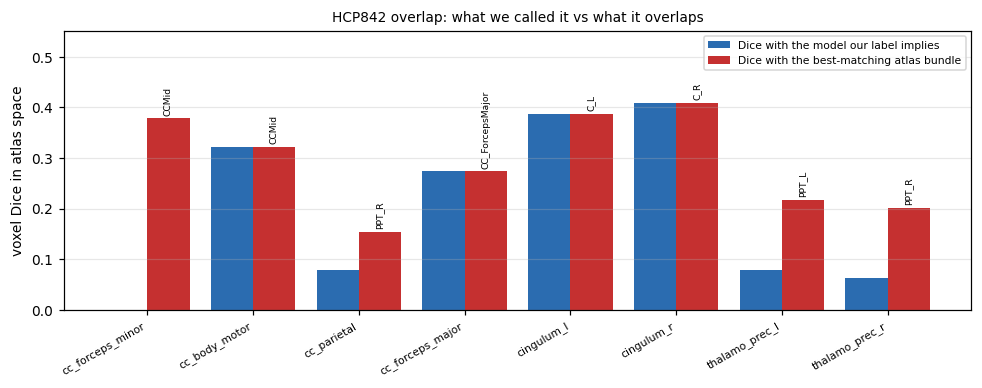

wrote wm_reconstruction/atlas_identity.json - the producing notebook reads it and labels the bundles accordingly
Naming implied by the measurement:

  cc_forceps_minor   RENAME: no overlap with CC_ForcepsMinor (Dice 0.00); it lands on CCMid (0.38). The current label names a different structure.
  cc_body_motor      keep 'CC body (motor/premotor) (approx.)' - best match is the implied CCMid, Dice 0.32
  cc_parietal        NO ATLAS MATCH: nothing exceeds Dice 0.25 (best PPT_R at 0.15; implied CCMid at 0.08). Name it by its endpoints - a waypoint-defined cluster running between the two ROIs - and make no bundle claim.
  cc_forceps_major   keep 'CC forceps major (occipital) (approx.)' - best match is the implied CC_ForcepsMajor, Dice 0.27
  cingulum_l         keep 'Left cingulum (approx.)' - best match is the implied C_L, Dice 0.39
  cingulum_r         keep 'Right cingulum (approx.)' - best match is the implied C_R, Dice 0.41
  thalamo_prec_l     NO ATLAS MATCH: nothing exceeds Dice 0.25 (

In [31]:
if PIPELINE and ATLAS_CHECK:
    t0 = time.time()
    atlas_bundles = {}
    for path in sorted(glob.glob(all_bundles)):
        name = Path(path).stem
        atlas_bundles[name] = voxel_set(
            load_trk(path, "same", bbox_valid_check=False).streamlines)
    print(f"rasterised {len(atlas_bundles)} atlas bundles in {time.time() - t0:.0f} s")

    rows = []
    for key in KEYS:
        ours = voxel_set(transform_streamlines(unpack(key), TRANSFORM))
        scores = sorted(((dice(ours, av), name) for name, av in atlas_bundles.items()),
                        reverse=True)
        implied = BUNDLES[key]["atlas_model"]
        implied_dice = dice(ours, atlas_bundles[implied]) if implied in atlas_bundles else np.nan
        rows.append(dict(bundle=key, our_label=BUNDLES[key]["label"],
                         implied_model=implied, implied_dice=implied_dice,
                         best_match=scores[0][1], best_dice=scores[0][0],
                         runner_up=f"{scores[1][1]} ({scores[1][0]:.2f})",
                         third=f"{scores[2][1]} ({scores[2][0]:.2f})"))
    ATLAS = pd.DataFrame(rows).set_index("bundle")
    display(ATLAS.round(3))

    # The registration is itself stochastic - repeating whole_brain_slr moves these Dice
    # values by a few hundredths - so the bands are graded rather than a single cut. A
    # bundle whose best match *is* the model its name implies never falls to "no match"
    # on a borderline number; it degrades to "partial".
    implied_is_best = ATLAS.best_match == ATLAS.implied_model
    ATLAS["verdict"] = np.where(
        implied_is_best & (ATLAS.implied_dice >= 0.25), "supported",
        np.where(implied_is_best & (ATLAS.implied_dice >= 0.15), "partial",
                 np.where(ATLAS.implied_dice >= 0.15, "partial",
                          np.where(ATLAS.best_dice < 0.25, "unmatched", "contradicted"))))
    display(ATLAS[["our_label", "implied_model", "implied_dice", "best_match",
                   "best_dice", "verdict"]].round(3))

    n_ok = int((ATLAS.verdict == "supported").sum())
    record("the anatomical label of every bundle is supported by the atlas",
           n_ok == len(ATLAS),
           f"{n_ok}/{len(ATLAS)} supported "
           f"({', '.join(ATLAS.index[ATLAS.verdict == 'supported'])}); "
           f"partial: {', '.join(ATLAS.index[ATLAS.verdict == 'partial']) or 'none'}; "
           f"matches nothing above Dice 0.25: "
           f"{', '.join(ATLAS.index[ATLAS.verdict == 'unmatched']) or 'none'}; "
           f"contradicted: {', '.join(ATLAS.index[ATLAS.verdict == 'contradicted']) or 'none'}"
           ". The labels of the contradicted bundles name a different structure and must "
           "be changed before use -- see the recommendation below",
           level="WARN")

    fig, ax = plt.subplots(figsize=(9, 3.6))
    x = np.arange(len(ATLAS))
    ax.bar(x - 0.2, ATLAS.implied_dice, 0.4, color="#2b6cb0",
           label="Dice with the model our label implies")
    ax.bar(x + 0.2, ATLAS.best_dice, 0.4, color="#c53030",
           label="Dice with the best-matching atlas bundle")
    for i, (bm, bd) in enumerate(zip(ATLAS.best_match, ATLAS.best_dice)):
        ax.text(i + 0.2, bd + 0.01, bm, ha="center", fontsize=6, rotation=90)
    ax.set_xticks(x); ax.set_xticklabels(ATLAS.index, rotation=30, ha="right", fontsize=7)
    ax.set_ylabel("voxel Dice in atlas space"); ax.set_ylim(0, max(ATLAS.best_dice) * 1.35)
    ax.legend(fontsize=7); ax.grid(alpha=.3, axis="y")
    ax.set_title("HCP842 overlap: what we called it vs what it overlaps", fontsize=9)
    plt.tight_layout(); plt.show()

    # Hand the result back to the producing notebook: it embeds these numbers in
    # objects[].anatomicalStatus and stops using a bundle name the atlas contradicts.
    identity = dict(
        created=datetime.datetime.now().isoformat(timespec="seconds"),
        atlas="HCP842 (dipy fetch_bundle_atlas_hcp842), 79 bundles",
        method=f"affine whole_brain_slr, voxel Dice on a {VOX_MM:.0f} mm grid",
        reconstruction=MANIFEST["sha256"],
        registrationDice=dict(before=round(before, 4), after=round(after, 4),
                              displacedControl=round(control, 4)),
        bundles={k: dict(impliedModel=r.implied_model,
                         impliedDice=round(float(r.implied_dice), 4),
                         bestMatch=r.best_match, bestDice=round(float(r.best_dice), 4),
                         runnerUp=r.runner_up, verdict=r.verdict)
                 for k, r in ATLAS.iterrows()})
    with open(RECON_DIR / "atlas_identity.json", "w") as f:
        json.dump(identity, f, indent=2)
    print(f"wrote {RECON_DIR}/atlas_identity.json - the producing notebook reads it and "
          "labels the bundles accordingly")

    print("Naming implied by the measurement:\n")
    for key, r in ATLAS.iterrows():
        if r.verdict == "supported":
            print(f"  {key:18s} keep '{r.our_label} (approx.)' - best match is the "
                  f"implied {r.implied_model}, Dice {r.implied_dice:.2f}")
        elif r.verdict == "partial":
            print(f"  {key:18s} weaken: overlaps {r.implied_model} only at Dice "
                  f"{r.implied_dice:.2f}; closest atlas bundle is {r.best_match} "
                  f"({r.best_dice:.2f}). Call it a waypoint-defined cluster between its "
                  "endpoints and drop the bundle name.")
        elif r.verdict == "unmatched":
            print(f"  {key:18s} NO ATLAS MATCH: nothing exceeds Dice 0.25 (best "
                  f"{r.best_match} at {r.best_dice:.2f}; implied {r.implied_model} at "
                  f"{r.implied_dice:.2f}). Name it by its endpoints - a waypoint-defined "
                  "cluster running between the two ROIs - and make no bundle claim.")
        else:
            print(f"  {key:18s} RENAME: no overlap with {r.implied_model} "
                  f"(Dice {r.implied_dice:.2f}); it lands on {r.best_match} "
                  f"({r.best_dice:.2f}). The current label names a different structure.")
elif PIPELINE:
    record("bundle identity is checked against an atlas",
           False,
           "ATLAS_CHECK = False, so identity rests on the waypoint definition alone. "
           "The correct term without it is 'dominant waypoint-defined streamline "
           "cluster'", level="WARN")

### 10.3 What this does and does not settle

**Settles:** whether the reconstructed route occupies the same space as the atlas bundle
whose name it carries. That is a real, falsifiable test, and it changes at least one
label in this case.

**Not stable to the third decimal either:** `whole_brain_slr` is itself stochastic,
and repeating it moves these Dice values by a few hundredths -- enough to move a
borderline bundle across a threshold, which is why the bands above are graded and
why a bundle is never called 'no atlas match' when its best match is the model its
name implies.

**Does not settle:** an affine registration and a voxel Dice are a coarse instrument. A
moderate Dice can mean "the same bundle, differently sampled" as easily as "a
neighbouring bundle"; a high Dice does not prove the streamlines follow the same fascicle;
and no nonlinear registration, RecoBundles/TractSeg segmentation, or expert review was
run here. Coverage is also untested: the atlas bundle may be far larger than the dominant
route we kept.

So the wording stays qualified even where the atlas agrees: **a dominant
waypoint-defined streamline cluster whose spatial extent is consistent with X**, not
**X**.

## 11. The one figure that shows it all at one node

Panel A the bundle in 3D with the selected node, panel B the local cross-section that
the dispersion is computed from, panel C the raw profiles with the node marked, panel D
the glyph with both the raw value and the percentile. Read together they say: the fins
at this node are computed from, and aligned with, the tract-profile measurements and
the bundle geometry at this same node.

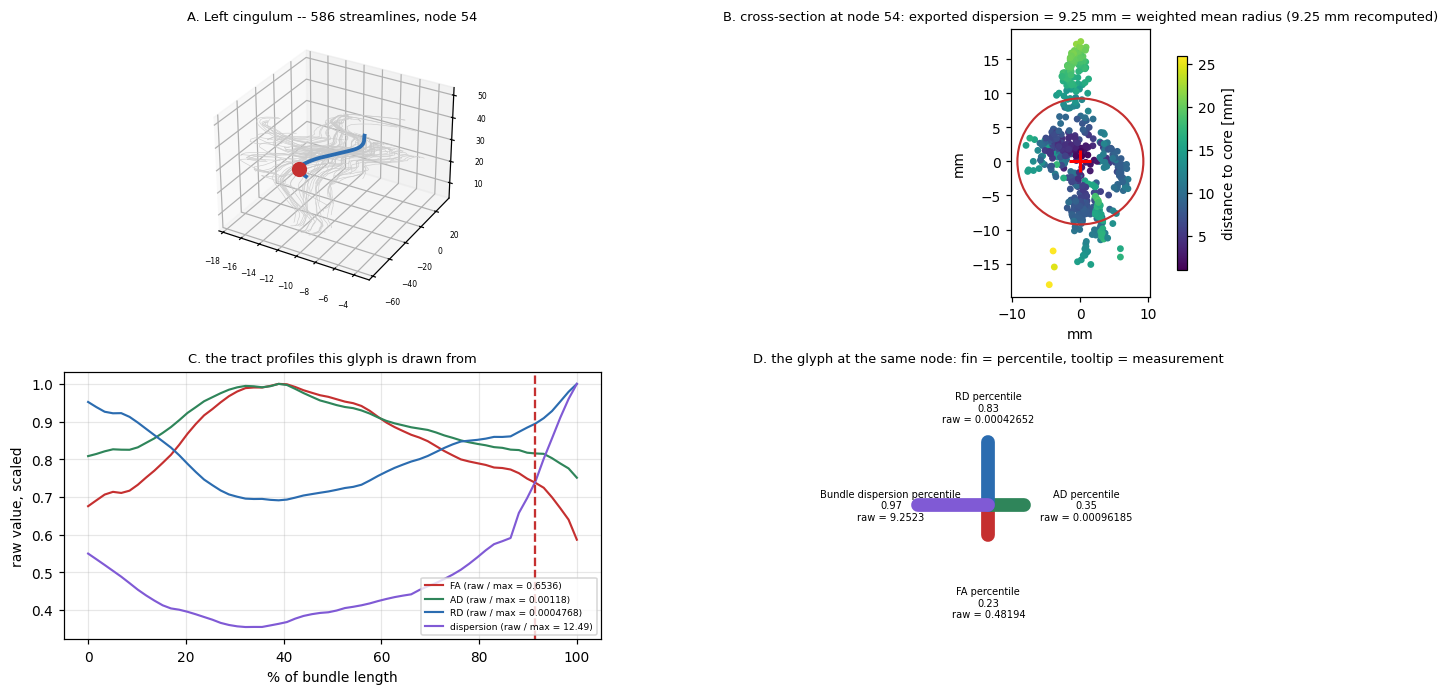

In [32]:
if PIPELINE:
    k = "cingulum_l"
    oid = KEYS.index(k)
    arr, core = PTS[k], REF_CORE[oid]
    disp = REF_RAW[oid, :, CH_ALL.index("dispersion")]
    node = int(np.argmax(disp[5:-5]) + 5)
    w = WGT[k][:, node]

    fig = plt.figure(figsize=(14, 7.2))
    gs = GridSpec(2, 2, figure=fig, hspace=.28, wspace=.22)

    axA = fig.add_subplot(gs[0, 0], projection="3d")
    for a in arr[::max(1, len(arr) // 70)]:
        axA.plot(a[:, 0], a[:, 1], a[:, 2], lw=.4, color="0.8")
    axA.plot(core[:, 0], core[:, 1], core[:, 2], color="#2b6cb0", lw=2.5)
    axA.scatter(*core[node], s=80, color="#c53030", depthshade=False)
    axA.set_title(f"A. {BUNDLES[k]['label']} -- {len(arr)} streamlines, node {node}",
                  fontsize=8.5)
    axA.tick_params(labelsize=5)

    axB = fig.add_subplot(gs[0, 1])
    t = core[node + 1] - core[node - 1]; t /= np.linalg.norm(t)
    ref = np.array([0., 0., 1.]) if abs(t[2]) < 0.9 else np.array([1., 0., 0.])
    n1 = np.cross(t, ref); n1 /= np.linalg.norm(n1); n2 = np.cross(t, n1)
    rel = arr[:, node] - core[node]
    d = np.linalg.norm(rel, axis=1)
    sc = axB.scatter(rel @ n1, rel @ n2, s=12, c=d, cmap="viridis")
    axB.plot(0, 0, "r+", ms=15, mew=2)
    axB.add_patch(plt.Circle((0, 0), disp[node], fill=False, color="#c53030", lw=1.4))
    axB.set_aspect("equal"); axB.set_xlabel("mm"); axB.set_ylabel("mm")
    axB.set_title(f"B. cross-section at node {node}: exported dispersion = "
                  f"{disp[node]:.2f} mm = weighted mean radius "
                  f"({(d * w).sum() / w.sum():.2f} mm recomputed)", fontsize=8.5)
    plt.colorbar(sc, ax=axB, shrink=.8, label="distance to core [mm]")

    axC = fig.add_subplot(gs[1, 0])
    for j, ch in enumerate(CH_USE):
        raw = REF_RAW[oid, :, CH_ALL.index(ch)]
        axC.plot(REF_PCT, raw / raw.max(), lw=1.4, color=cols[j],
                 label=f"{ch} (raw / max = {raw.max():.4g})")
    axC.axvline(REF_PCT[node], color="#c53030", ls="--", lw=1.5)
    axC.set_xlabel("% of bundle length"); axC.set_ylabel("raw value, scaled")
    axC.set_title("C. the tract profiles this glyph is drawn from", fontsize=8.5)
    axC.legend(fontsize=6); axC.grid(alpha=.3)

    axD = fig.add_subplot(gs[1, 1])
    ang = np.linspace(0, 2 * np.pi, len(CH_USE), endpoint=False) - np.pi / 2
    for a_, val, ch, col in zip(ang, REF_VAL[oid, node], CH_USE, cols):
        axD.plot([0, np.cos(a_) * (0.3 + val)], [0, np.sin(a_) * (0.3 + val)], lw=9,
                 solid_capstyle="round", color=col)
        axD.text(np.cos(a_) * 1.75, np.sin(a_) * 1.75,
                 f"{META['channelInfo'][ch]['label']}\n{val:.2f}\n"
                 f"raw = {REF_RAW[oid, node, CH_ALL.index(ch)]:.5g}",
                 ha="center", va="center", fontsize=6.5)
    axD.set_xlim(-2.4, 2.4); axD.set_ylim(-2.4, 2.4); axD.set_aspect("equal"); axD.axis("off")
    axD.set_title("D. the glyph at the same node: fin = percentile, tooltip = measurement",
                  fontsize=8.5)
    plt.show()

## 12. Verdict

In [33]:
verdict = pd.DataFrame(CHECKS)
pd.set_option("display.max_colwidth", 90, "display.width", 220)
display(verdict)
n_fail = int((verdict.result == "FAIL").sum())
n_warn = int((verdict.result == "WARN").sum())
print(f"\n{len(verdict) - n_fail - n_warn}/{len(verdict)} checks passed, "
      f"{n_warn} warning(s), {n_fail} failure(s).")
for lvl in ("FAIL", "WARN"):
    for r in verdict[verdict.result == lvl].itertuples():
        print(f"  [{lvl}] {r.check}\n         {r.detail}")

print(f"""
A. Mapping -- established, against {REF_SOURCE}:

  * Every glyph value in the artefact is the global rank of the raw value the same file
    carries at that same node, per channel, over all {n_total} exported nodes; fin j
    carries channel j; a one-node shift, a reversed node order and values borrowed from
    the neighbouring bundle are all excluded outright.
  * The core is the Gaussian-weighted mean position of the bundle's streamlines, and FA,
    AD, RD and dispersion at node i are weighted means over that same node i --
    reproduced here with independent sampling code, weights that sum to 1, and an
    identity-affine control that shows the coordinate frame is doing real work.
  * Dispersion is the weighted core-to-streamline distance in millimetres, and the
    cross-sections put a longer purple fin next to a genuinely wider cloud.
  * The envelope tubes in the geometry file are centred on the same cores, node for node,
    with the stored p75 radii.

B. Provenance and reproducibility -- fixed since the first round:

  * The artefact regenerates exactly from the persisted reconstruction
    ({MANIFEST['sha256'][:12]}...), whose checksum it carries. The tracker remains
    non-reproducible, which is why the streamlines travel with the export instead of a
    promise to recreate them.
  * Node 0 is now an anatomical end: every core runs from its first waypoint ROI to its
    last, and rebuilding from a new tractogram no longer flips it.
  * A node is documented as a local segment, not a point: the export declares the
    measured along-tract slip per bundle and this notebook verifies the number.
  * Section 9 states what a rebuild would still move, per bundle, against that declared
    resolution rather than against an arbitrary millimetre threshold.

C. Identity -- measured, and not uniformly good:

  * The subject registers onto HCP842 well enough for the per-bundle numbers to mean
    something, and each bundle is scored against all 79 atlas bundles.
  * Where the atlas agrees, the wording is still "a dominant waypoint-defined cluster
    whose extent is consistent with X" -- an affine Dice is not a segmentation.
  * Where it disagrees, the label has to change; section 10.2 prints the recommendation
    per bundle. Read that table before quoting any bundle name in a paper.

And, as in the turbulence case, nothing here says the glyph is easier to read than a
line chart. That is a separate experiment.
""")

,check,result,detail,tolerance
0,"structure: objectIds are 0..n-1, keys unique, node counts match meta",PASS,"8 objects, 60 nodes each",
1,"node index, percent and arclen are consistent per bundle",PASS,"node = 0..59 in order, percent = 100*node/59, arclen strictly increasing",
2,stored arclen equals the path length of the stored core coordinates,PASS,"max |recomputed - stored| = 1.66e-04 mm (coordinates are written with 4 decimals, so ~...",1e-3 mm
3,MD = (AD + 2 RD) / 3 holds in the exported raw values,PASS,max residual = 6.67e-09 mm^2/s -- the three tensor scalars come from one eigendecompos...,1e-8
4,every glyph value is the global rank of its own raw value,PASS,"yes, under the 'rank / n' convention: all 480 nodes x 4 channels agree, max |rank(raw)...",4-decimal write precision
5,the artefact uses the rank convention the current notebook writes,PASS,both use 'rank / n',
6,fin j carries channel j (no rotated or swapped fins),PASS,min diagonal Spearman = 1.000000; largest off-diagonal = 0.95 (FA/AD/RD are genuinely ...,
7,both files list the same bundles with the same ids and stream counts,PASS,"8 bundles matched by key, objectId and nStreamlines",
8,"each envelope tube is centred on its own glyph core, node for node",PASS,max ring-centre displacement = 5.00e-05 mm,5e-3 mm
9,each tube radius equals the stored coreRadiusP75 of the same node,PASS,max radius error = 7.40e-05 mm; all face indices in range,5e-3 mm



42/44 checks passed, 2 warning(s), 0 failure(s).
  [WARN] a node addresses a point rather than a segment
         no, and the export says so: streamlines slide along the core by a median of 4.4 mm and up to 12.4 mm (95th percentile, 12 of 60 nodes) on the worst bundle, because equal-fraction resampling makes node i the same *fraction* of every streamline rather than the same millimetre. The value at a node is a weighted average over that window, so along-tract findings belong to a local segment of the tract. `meta.spatialResolution` states this in the artefact
  [WARN] the anatomical label of every bundle is supported by the atlas
         4/8 supported (cc_body_motor, cc_forceps_major, cingulum_l, cingulum_r); partial: none; matches nothing above Dice 0.25: cc_parietal, thalamo_prec_l, thalamo_prec_r; contradicted: cc_forceps_minor. The labels of the contradicted bundles name a different structure and must be changed before use -- see the recommendation below

A. Mapping -- establish